In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import io
import anndata
import random
from matplotlib.ticker import MaxNLocator

random.seed(777)

import celloracle as co
co.__version__

# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 6]
plt.rcParams["savefig.dpi"] = 300

#GRN model construction and network analysis
#https://morris-lab.github.io/CellOracle.documentation/tutorials/networkanalysis.html


/opt/conda/envs/celloracle2/lib/python3.8/site-packages/logomaker/src/validate.py:98: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if matrix_type is 'information':
/opt/conda/envs/celloracle2/lib/python3.8/site-packages/logomaker/src/validate.py:104: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif matrix_type is 'probability':


In [2]:
#Set working directory
os.chdir("/storage1/fs1/jmillman/Active/DigitalTwin")

save_folder = "outputs/celloracle_figures"


# GRN model construction preprocessing

In [44]:
X = io.mmread('checkpoints/DT_Subset_DE_GT_PP_matrix.mtx')

adata= anndata.AnnData(X=X.transpose().tocsr())

metadata = pd.read_csv('checkpoints/DT_Subset_DE_GT_PP_metadata.csv')

with open ('checkpoints/DT_Subset_DE_GT_PP_gene_names.csv', 'r' ) as f:
    gene_names = f.read().splitlines()
    
adata.obs = metadata
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

pca = pd.read_csv('checkpoints/DT_Subset_DE_GT_PP_pca.csv')
pca.index = adata.obs.index

adata.obsm['X_pca'] = pca.to_numpy()
adata.obsm['X_umap'] = np.vstack((adata.obs['UMAP_1'].to_numpy(), 
                                  adata.obs['UMAP_2'].to_numpy())).T

... storing 'orig.ident' as categorical
... storing 'modality' as categorical
... storing 'dataset' as categorical
... storing 'protocol' as categorical
... storing 'stage' as categorical
... storing 'day' as categorical
... storing 'cellsource' as categorical
... storing 'gender' as categorical
... storing 'modality.1' as categorical
... storing 'dataset.1' as categorical
... storing 'protocol.1' as categorical
... storing 'stage.1' as categorical
... storing 'day.1' as categorical
... storing 'cellsource.1' as categorical
... storing 'gender.1' as categorical
... storing 'celltype_labelled_by_protocol' as categorical
... storing 'celltype_DE_GT_PP_subset' as categorical


PP    4160
DE    2578
GT    1946
Name: celltype_DE_GT_PP_subset, dtype: int64


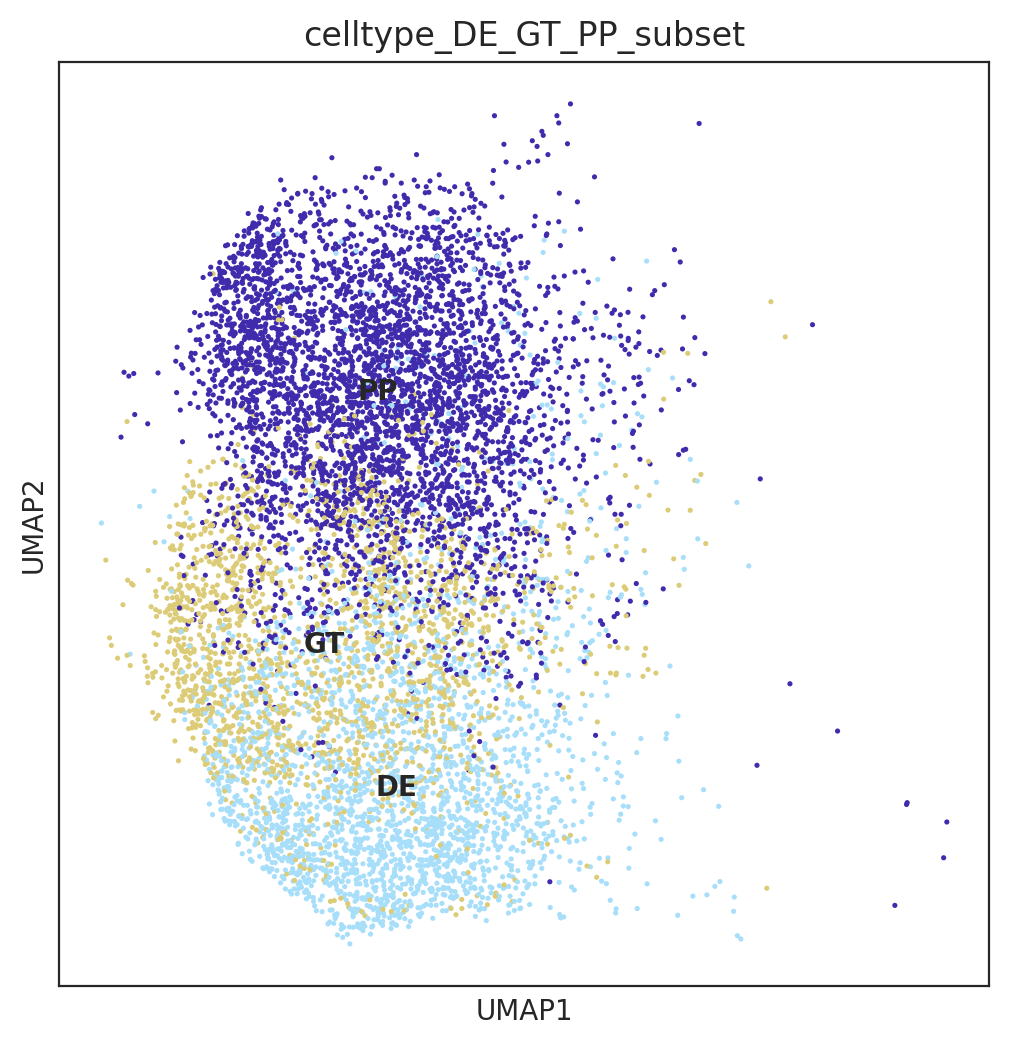

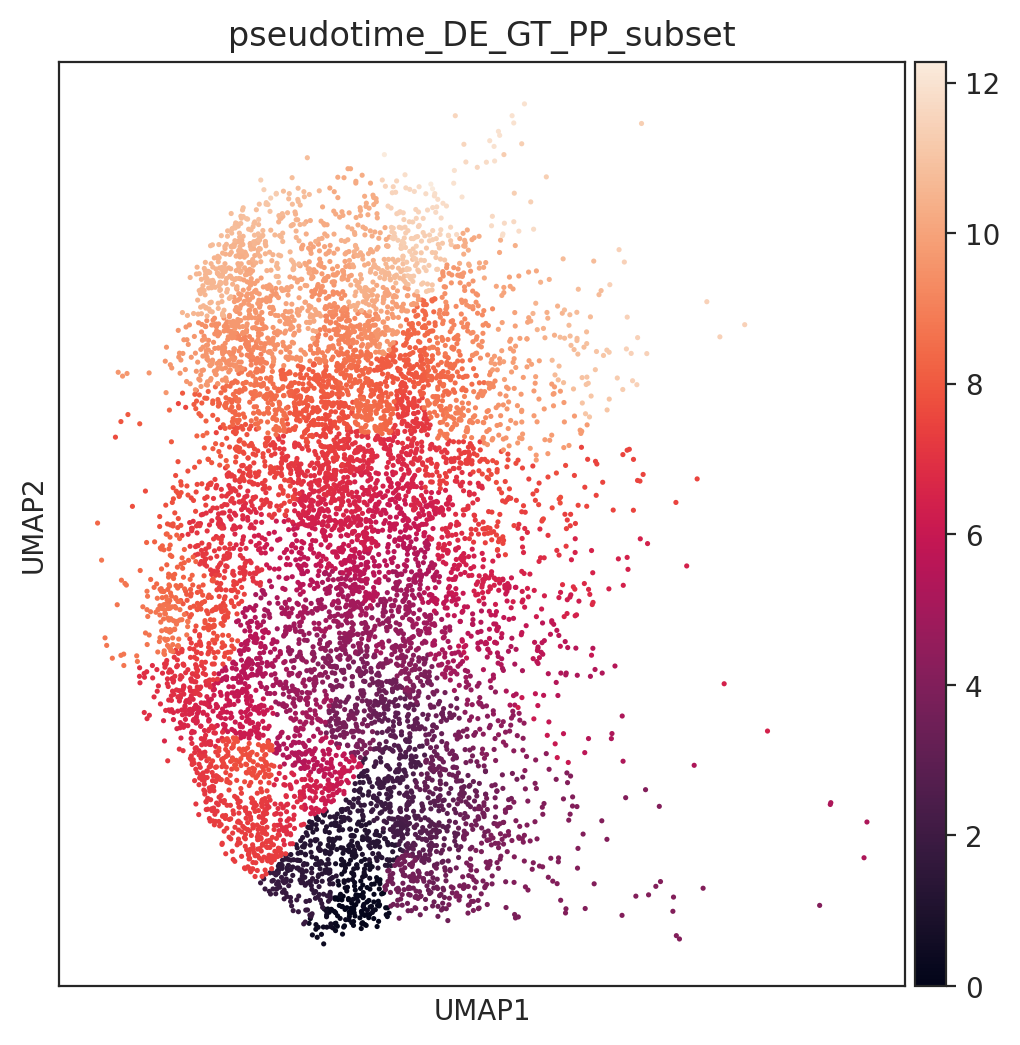

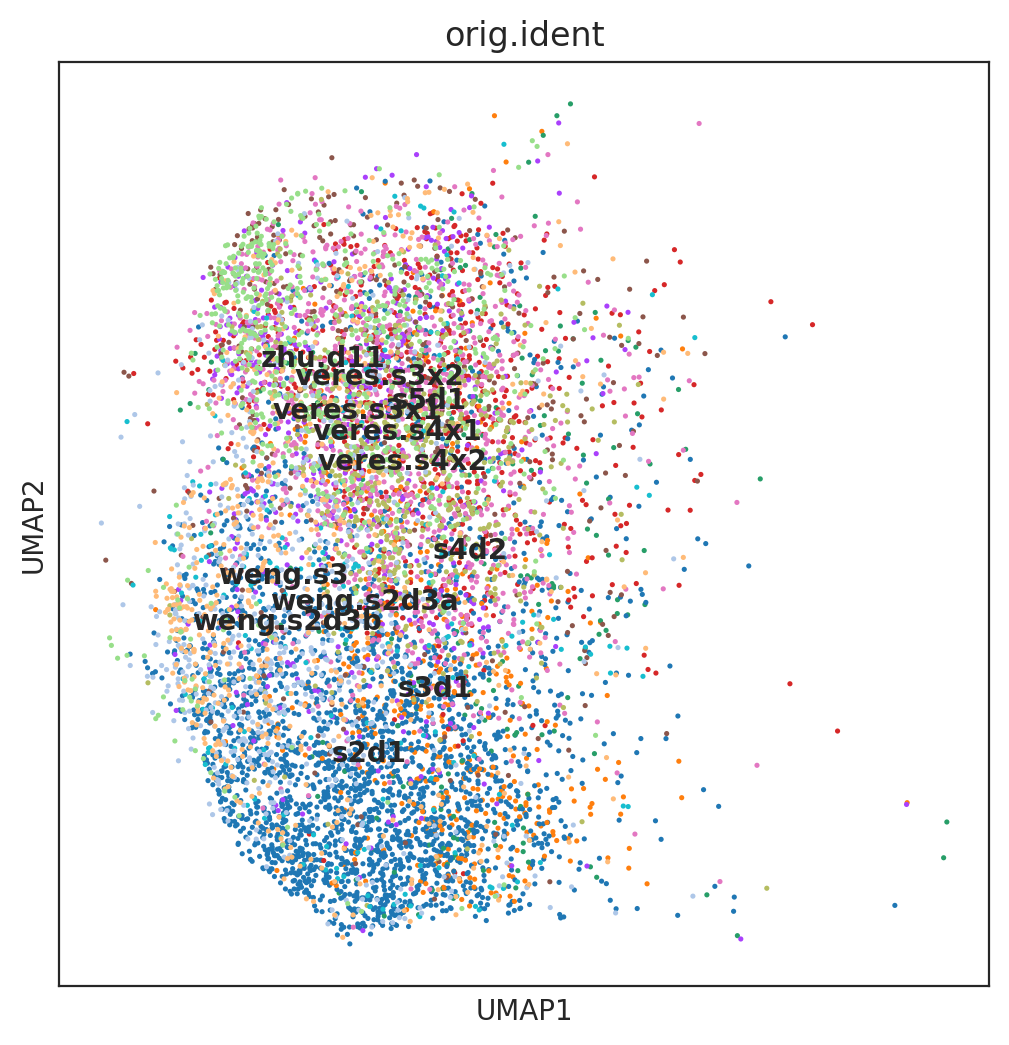

In [45]:
celltype_DE_GT_PP_subset_colors = ['#a7defa', "#DDCC77", "#402bad" ]
    
adata.uns["celltype_DE_GT_PP_subset_colors"] = celltype_DE_GT_PP_subset_colors

# Check how many cells are per cell type
cell_types = adata.obs['celltype_DE_GT_PP_subset']
cluster_counts = pd.value_counts(cell_types)
print(cluster_counts)

sc.pl.umap(adata, color='celltype_DE_GT_PP_subset', legend_loc='on data')
sc.pl.umap(adata, color='pseudotime_DE_GT_PP_subset', legend_loc='on data')
sc.pl.umap(adata, color='orig.ident', legend_loc='on data')

In [46]:
# Filter highly variable genes
filter_result = sc.pp.filter_genes_dispersion(adata.X, flavor='seurat', 
                                              n_top_genes=3000, log=False)

# Additional genes to include
# Including genes: from Differentiated human stem cells resemble fetal, not adult, β cells
additional_genes = ['ABCC8','ACOX2','ACSS3','AFP','AHR','ALDOA','ALX1',
                    'AR','ARX','ARHGEF12','ARID2','ARID5B','ARNT2','ARX',
                    'ASCL1','ASCL2','ATF2','ATF6', 'ATP5MC3','ATP6V0E1','BACH1',
                    'BACH2','BBX','BCL11A','BCLAF1','BDP1','BMP4',
                    'BPTF','CACNA1A','CACNA1B','CACNA1C','CACNA1E','CBX5',
                    'CCDC6','CDH1','CDH2','CDX2','CHD2','CHGB','CLOCK','CMIP',
                    'COL1A1','COX4I1','CREB1','CREB3L2','CREB5','CTCF',
                    'CTNNB1','CUX1','CUX2','DDC','DLL3',
                    'DPP4','E2F3','E2F7','EBF1','EBF3','ELF1','ELF2',
                    'ENO1','EPAS1','ESR1','ESR2','ESRRB','ESRRG','ETS1',
                    'ETS2','ETV1','ETV6','FEV','FFAR1',
                    'FOXA1','FOXA2','FOXA3','FOXC1','FOXJ3','FOXN2','FOXN3',
                    'FOXO1','FOXO3','FOXP1','FOXP2','GAST',
                    'GATA4','GATA6','GCG','GCH1','GCK','GHRL','GIP',
                    'GLI2','GLI3','GLIS3','GPI','GRHL2','GTF2I','HCN1','HCN2',
                    'HCN3','HCN4','HDAC2','HDX','HES1','HESX1','HHEX','HIF1A',
                    'HIVEP1','HIVEP2','HIVEP3','HLTF','HMGA2','HNF1A','HNF1B',
                    'HNF4A','HNF4G','IAPP','ID1',
                    'ID2','IKZF2','INS','INSM1','IRX1','IRX2','ISL1',
                    'ISX','JUN','KCNA3','KCNC2','KCNC4','KCNH2',
                    'KCNJ11','KCNJ2','KCNJ6','KCNK1','KCNK12','KCNK17',
                    'KCNMA1','KCNMB2','KCNN1','KLF12','KLF5','KLF7','LHX1',
                    'LHX4','LMO2','LMX1A','LMX1B','MAF','MAFB','MAOA',
                    'MAOB','MAP3K11','MECOM','MEF2A','MEF2C','MEIS1','MEIS2','MITF',
                    'MLXIPL','MMP2','MNX1','MXI1','MYCN','MYEF2','MYT1',
                    'NEUROD1','NEUROD4','NEUROG3','NF1','NFAT5','NFATC2','NFATC3',
                    'NFIA','NFIB','NFKB1','NKX2-2',
                    'NKX6-1','NNT','NPAS3','NR0B1','NR0B2',
                    'NR2C2','NR3C1','NR3C2','NR4A3','NR5A2','NR6A1','NRF1',
                    'ONECUT1','ONECUT2','ONECUT3','OSR1','OTX2',
                    'PAX4','PAX6','PBX1','PBX3','PCSK1','PDIA6','PDX1','PGAP1',
                    'PITX1','PITX2','PLAG1','PLAGL1','POU2F1',
                    'POU2F2','POU3F4','POU6F2','PPARG','PPY','PRDM16',
                    'PRDM5','PRKCSH','PRLR','PROX1','PTEN','PYY','RAD21',
                    'RAP1A','RBPJ','RFX1','RFX2','RFX3','RFX4','RFX6','RFX7','RIMS1',
                    'RIMS2','RIMS4','RORA','RORB','RREB1','RUNX1','RXRA','RXRB',
                    'RXRG','SCN2A','SCN3A','SCT','SHH','SIM1',
                    'SIX2','SLC18A1','SLC2A1','SLC2A14','SLC2A2','SLC2A3','SLC30A8',
                    'SLC6A4','SMAD2','SMAD3','SMARCA1','SMARCA5','SMARCC1','SMC3',
                    'SNAP25','SOX11','SOX2','SOX4','SOX6','SOX9','SOX17',
                    'SREBF2','SRY','SSTR2','STAT1','STAT4','STX1A','STXBP1','SYP',
                    'SYT4','SYT7','TBX3','TCF12','TCF4','TCF7L1','TCF7L2',
                    'TEAD1','TFDP2','THRA','THRB','TP63','TPH1','UCN3',
                    'VAMP2','WNT4','WNT5A','XBP1','ZBTB16',
                    'ZBTB7C','ZEB1','ZFHX3','ZKSCAN1','ZNF148','ZNF423','ZNF431',
                    'ZNF652','ZNF708']
#Out:

# Get the indices of genes that passed the filtering
selected_indices = np.where(filter_result.gene_subset)[0]

# Add indices of additional genes
additional_gene_indices = [adata.var_names.get_loc(gene) for gene in additional_genes]

# Combine indices and make them unique
all_selected_indices = np.concatenate([selected_indices, additional_gene_indices])
all_selected_indices = np.unique(all_selected_indices)

# Subset the data using selected indices
adata = adata[:, all_selected_indices]

adata

View of AnnData object with n_obs × n_vars = 8684 × 3139
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels', 'modality.1', 'dataset.1', 'protocol.1', 'stage.1', 'day.1', 'cellsource.1', 'gender.1', '_indices.1', '_scvi_batch.1', '_scvi_labels.1', 'multivi_clusters', 'cell', 'celltype_labelled_by_protocol', 'RNA_snn_res.2', 'seurat_clusters', 'RNA_snn_res.2.5', 'RNA_snn_res.3', 'RNA_snn_res.1.5', 'celltype_DE_GT_PP_subset', 'pseudotime_DE_GT_PP_subset', 'barcode', 'UMAP_1', 'UMAP_2'
    uns: 'celltype_DE_GT_PP_subset_colors', 'orig.ident_colors'
    obsm: 'X_pca', 'X_umap'

In [47]:
#Downsampling
#If your scRNA-seq data includes more than 20-30K cells, we recommend downsampling your data. 
#If you do not, please note the perturbation simulations may require large amounts of memory in the next notebook.

print(f"Cell number is :{adata.shape[0]}")
print(f"Gene number is :{adata.shape[1]}")

# Random downsampling into 30K cells if the anndata object include more than 30 K cells.
n_cells_downsample = 30000 
if adata.shape[0] > n_cells_downsample:
    # Let's dowmsample into 30K cells
    sc.pp.subsample(adata, n_obs=n_cells_downsample, random_state=123)
    
print(f"Cell number is :{adata.shape[0]}")

Cell number is :8684
Gene number is :3139
Cell number is :8684


In [48]:
pseudotime_DT_Subset_DE_GT_PP = adata.obs['pseudotime_DE_GT_PP_subset']
pseudotime_DT_Subset_DE_GT_PP

cell_id = "s2d1_TGGTGCATCTTAGCCC-1_paired"

cell_id in pseudotime_DT_Subset_DE_GT_PP.index


True

In [49]:
#Load base-GRN data
base_GRN = pd.read_parquet("checkpoints/DT_27944_peaks_base_GRN_df.parquet",
                           engine='pyarrow')

# Check data
print(base_GRN.head(1))


                     peak_id gene_short_name  9430076C15RIK  AC002126.6  \
0  chr10_100009426_100010396           DNMBP              0           0   

   AC012531.1  AC226150.2  AFP  AHR  AHRR  AIRE  ...  ZNF784  ZNF8  ZNF816  \
0           0           0    0    0     0     0  ...       0     0       0   

   ZNF85  ZSCAN10  ZSCAN16  ZSCAN22  ZSCAN26  ZSCAN31  ZSCAN4  
0      0        0        0        0        0        0       0  

[1 rows x 1096 columns]


In [50]:
# Instantiate Oracle object
oracle = co.Oracle()


In [51]:
# Check data in anndata
print("Metadata columns :", list(adata.obs.columns))
print("Dimensional reduction: ", list(adata.obsm.keys()))

# The AnnData should have (1) gene expression counts, 
#(2) clustering information, and (3) trajectory (dimensional reduction embedding) data.


Metadata columns : ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels', 'modality.1', 'dataset.1', 'protocol.1', 'stage.1', 'day.1', 'cellsource.1', 'gender.1', '_indices.1', '_scvi_batch.1', '_scvi_labels.1', 'multivi_clusters', 'cell', 'celltype_labelled_by_protocol', 'RNA_snn_res.2', 'seurat_clusters', 'RNA_snn_res.2.5', 'RNA_snn_res.3', 'RNA_snn_res.1.5', 'celltype_DE_GT_PP_subset', 'pseudotime_DE_GT_PP_subset', 'barcode', 'UMAP_1', 'UMAP_2']
Dimensional reduction:  ['X_pca', 'X_umap']


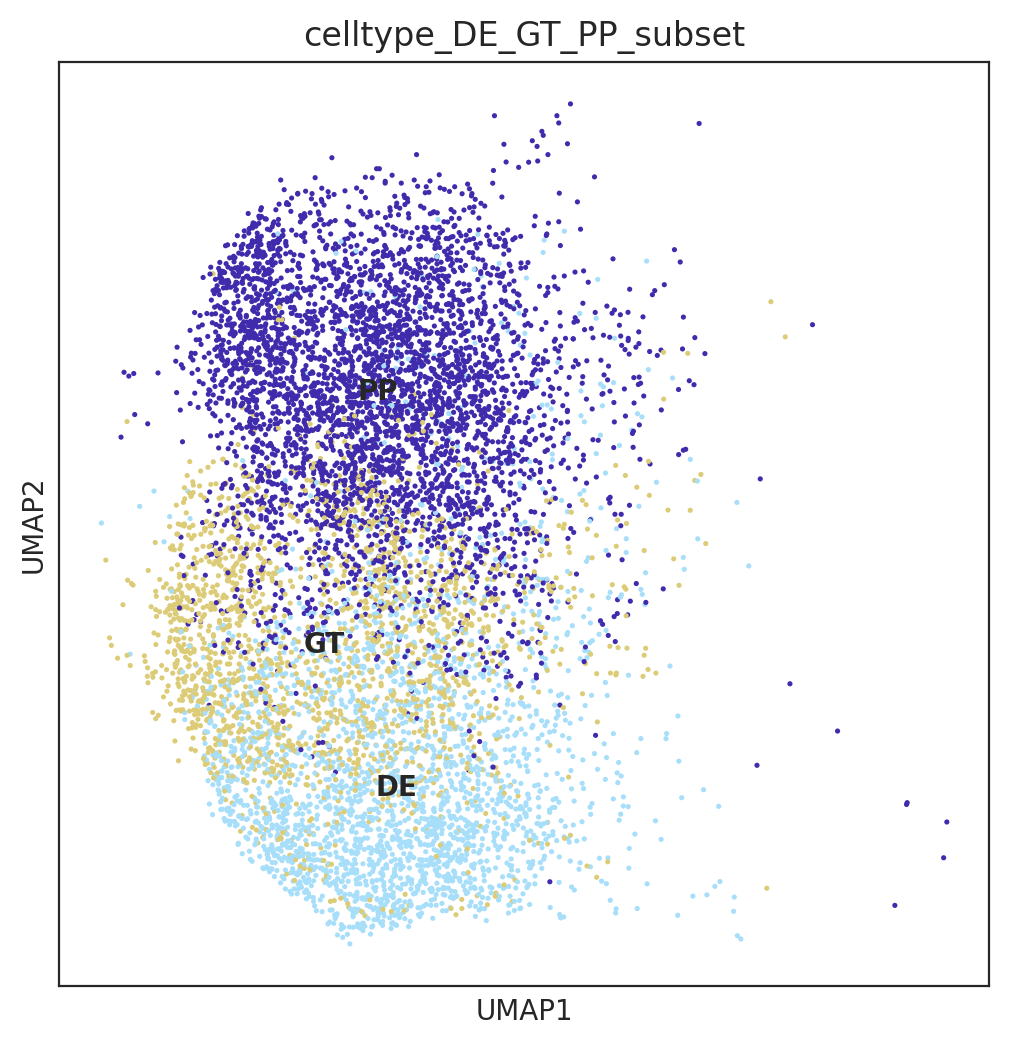

In [52]:
sc.pl.embedding(adata, basis='umap', color='celltype_DE_GT_PP_subset', legend_loc='on data')

adata.obs["celltype_DE_GT_PP_subset"] =adata.obs["celltype_DE_GT_PP_subset"].astype("category") 

In [53]:
adata.var

""
LINC01611
VCAN-AS1
CCL2
GATA3
LINC00458
...
ATP2B1
NTS
MGAT4C
LRRIQ1


In [54]:
pseudotime_DT_Subset_DE_GT_PP = adata.obs['pseudotime_DE_GT_PP_subset']
pseudotime_DT_Subset_DE_GT_PP

barcode
s4d2_CATCCCAGTGTGAGAG-1_paired            7.168216
s5d1_AAGGTGCAGCGCCTAA-1_paired           10.087364
s2d1_AGTGCCGGTAGCCATA-1_paired            7.033880
s2d1_GGAGTGAGTGAAACAA-1_paired            3.665726
s2d1_CGCACAATCTGTTCAT-1_paired            5.771441
                                           ...    
zhu.d11_TTTATGCAGCACTAAA-1_expression     8.124000
zhu.d11_TTTCGATGTATGCGGA-1_expression     6.313499
zhu.d11_TTTGACTGTGGAGGTT-1_expression     7.702205
zhu.d11_TTTGTTGCATAGTCAC-1_expression     9.445563
zhu.d11_TTTGTTGGTCTCGGAC-1_expression     8.521073
Name: pseudotime_DE_GT_PP_subset, Length: 8684, dtype: float64

In [55]:
#Prepare for Pseudotime
sc.pp.neighbors(adata, n_neighbors=10, method='umap', use_rep='X_umap')  # Adjust parameters as needed

In [56]:
sc.tl.diffmap(adata, n_comps=10)

In [57]:
# Check data in anndata
print("Metadata columns :", list(adata.obs.columns))
print("Dimensional reduction: ", list(adata.obsm.keys()))

# The AnnData should have (1) gene expression counts, 
#(2) clustering information, and (3) trajectory (dimensional reduction embedding) data.


Metadata columns : ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels', 'modality.1', 'dataset.1', 'protocol.1', 'stage.1', 'day.1', 'cellsource.1', 'gender.1', '_indices.1', '_scvi_batch.1', '_scvi_labels.1', 'multivi_clusters', 'cell', 'celltype_labelled_by_protocol', 'RNA_snn_res.2', 'seurat_clusters', 'RNA_snn_res.2.5', 'RNA_snn_res.3', 'RNA_snn_res.1.5', 'celltype_DE_GT_PP_subset', 'pseudotime_DE_GT_PP_subset', 'barcode', 'UMAP_1', 'UMAP_2']
Dimensional reduction:  ['X_pca', 'X_umap', 'X_diffmap']


In [58]:
#adata.X = adata.layers["raw_count"].copy()

# Instantiate Oracle object.
oracle.import_anndata_as_raw_count(adata=adata,
                                   cluster_column_name="celltype_DE_GT_PP_subset",
                                   embedding_name="X_umap")


In [59]:
#Load base-GRN data into oracle object
#You can load TF info dataframe with the following code.
oracle.import_TF_data(TF_info_matrix=base_GRN)


In [60]:
#KNN imputation

# Perform PCA
oracle.perform_PCA()


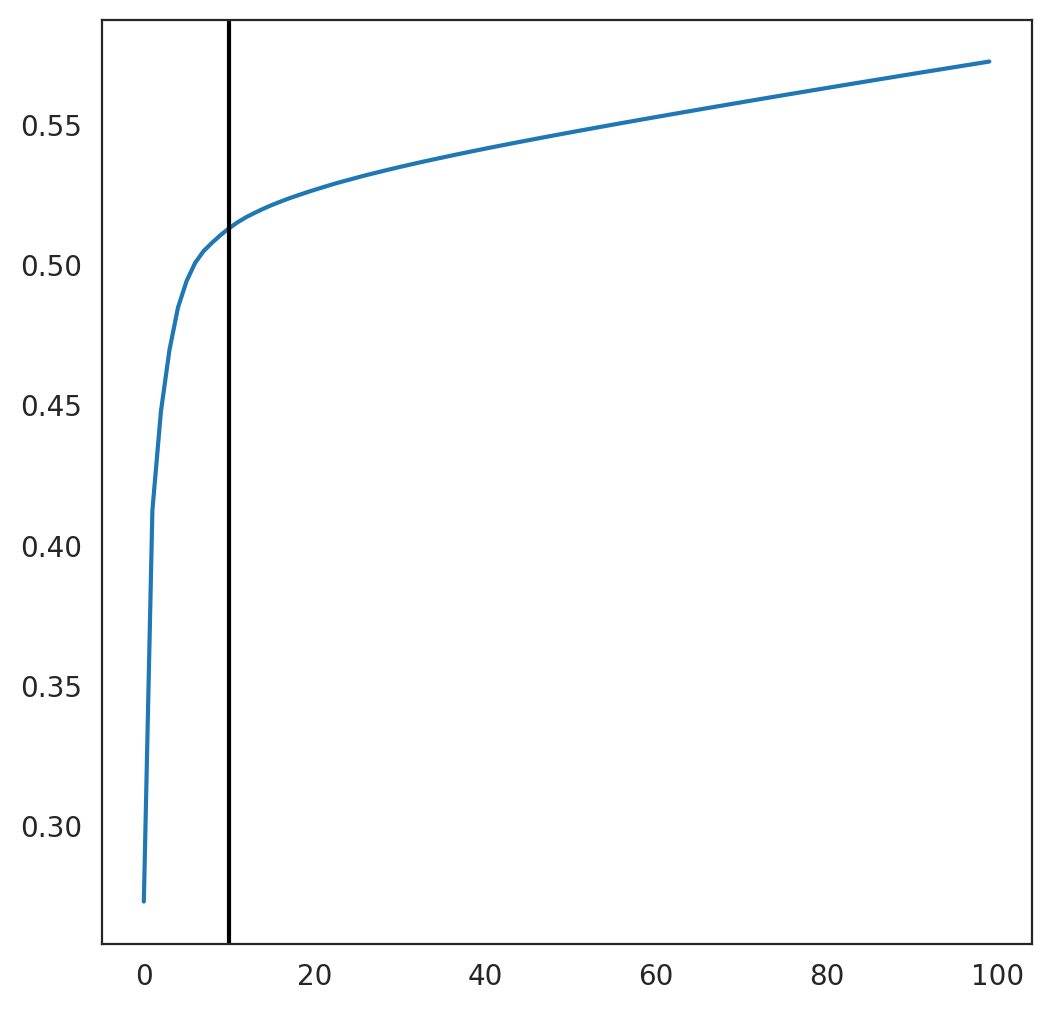

10


In [61]:
# Select important PCs
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)


In [62]:
#Estimate the optimal number of nearest neighbors for KNN imputation.

n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")

k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")

#KNN imputation
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=4)


cell number is :8684
Auto-selected k is :217


Clustering name:  celltype_DE_GT_PP_subset
Cluster list ['DE', 'GT', 'PP']


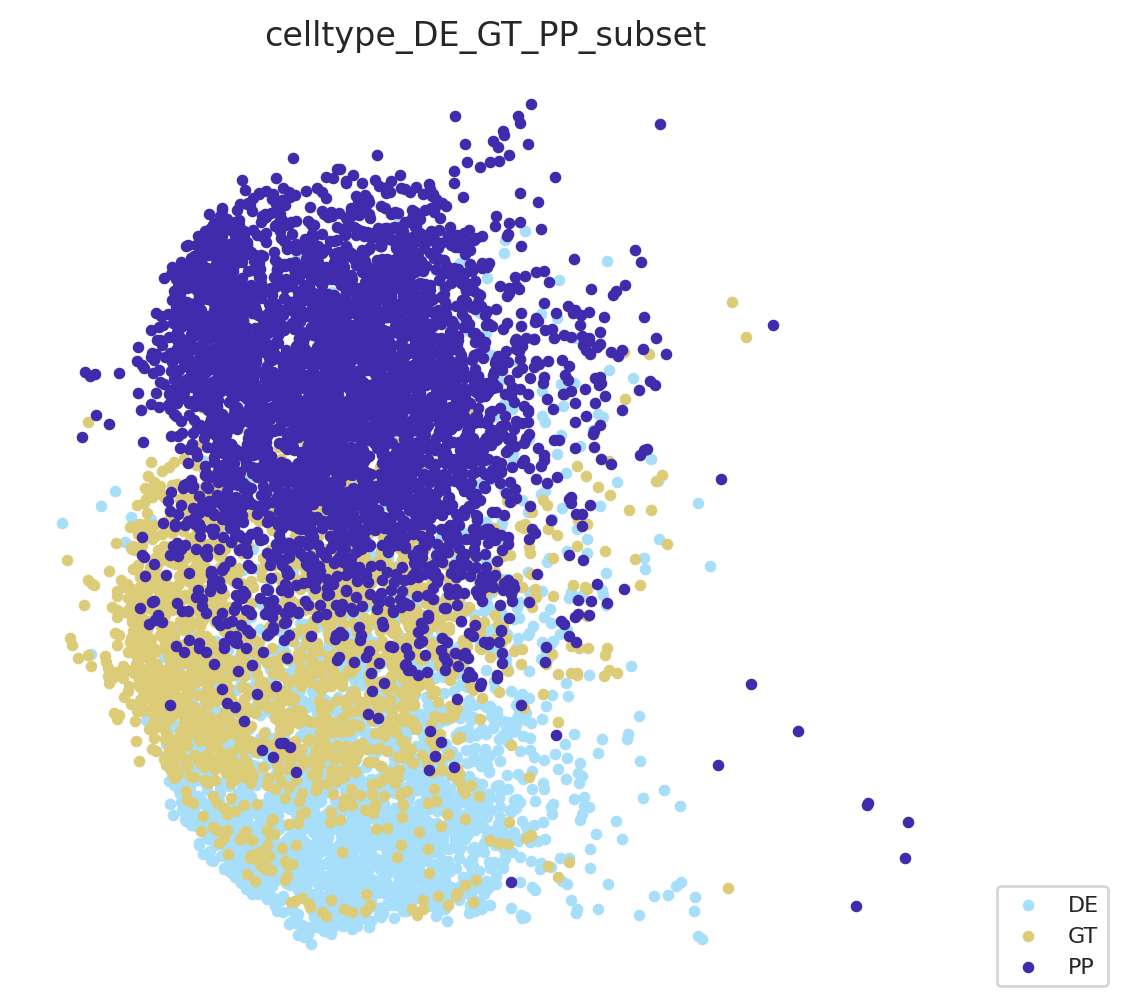

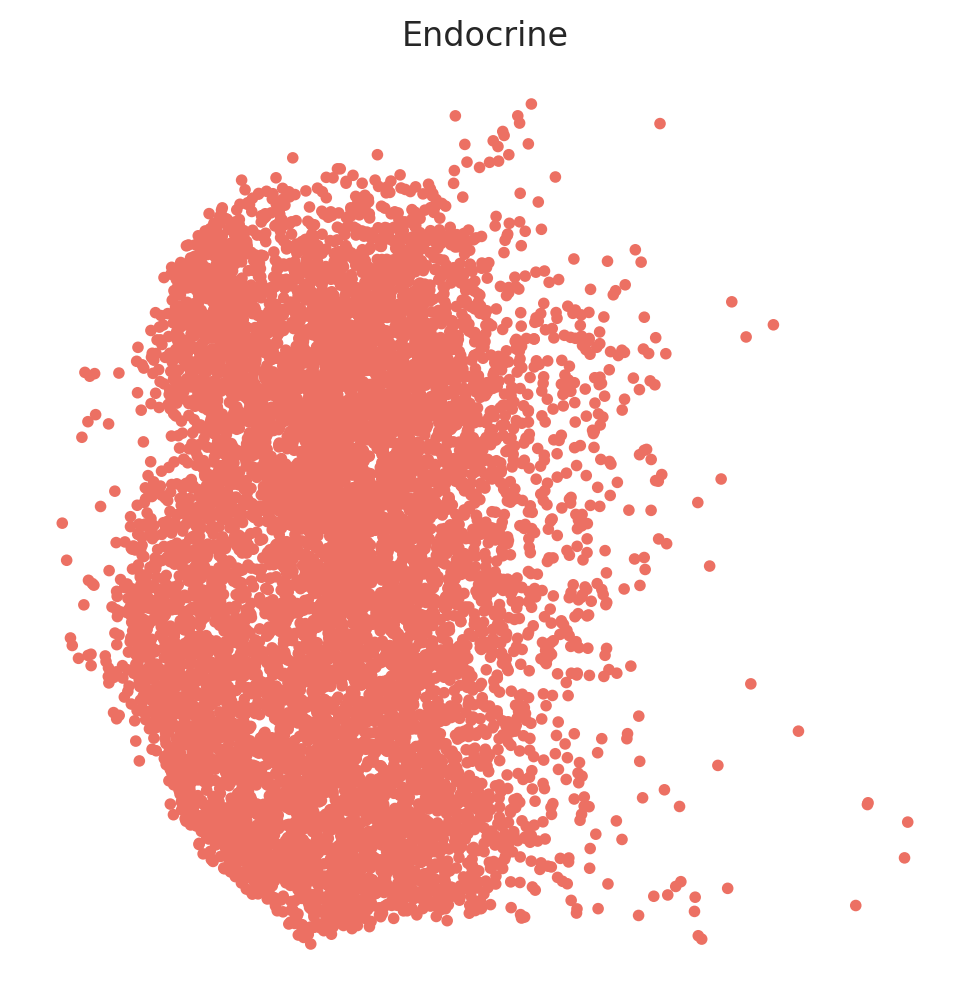

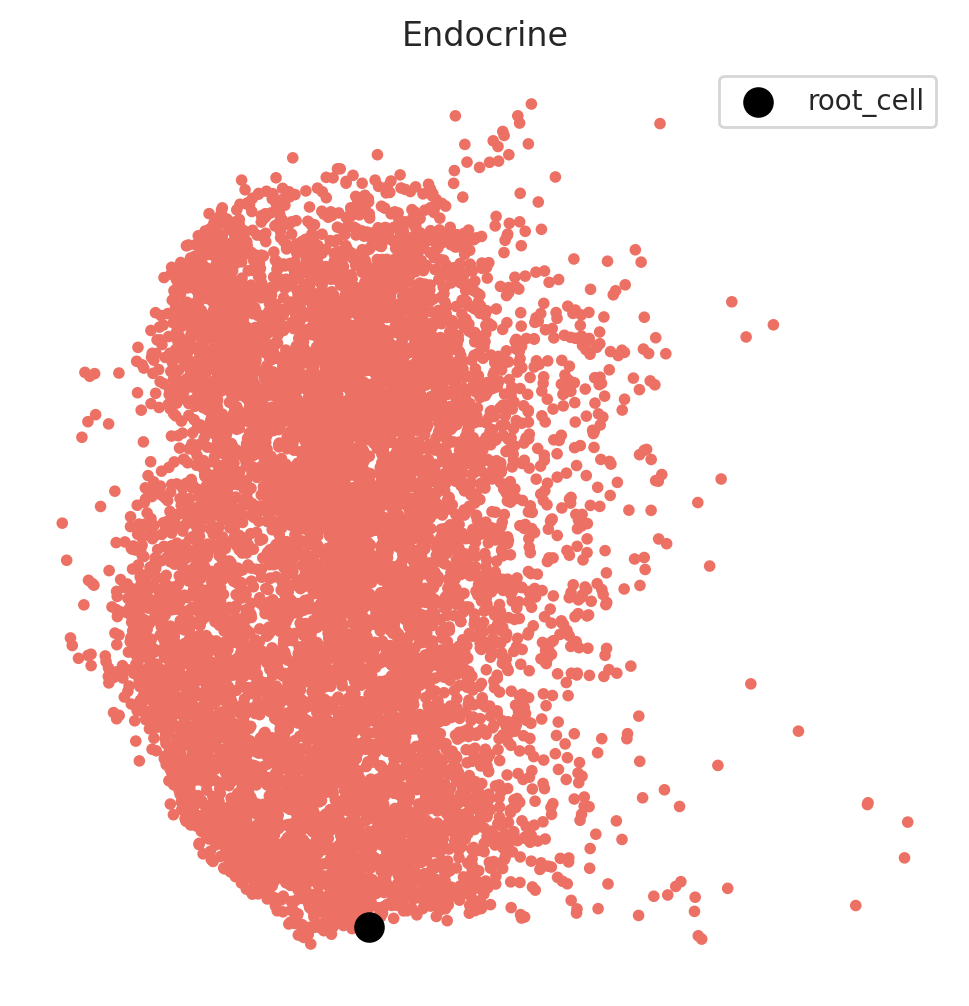

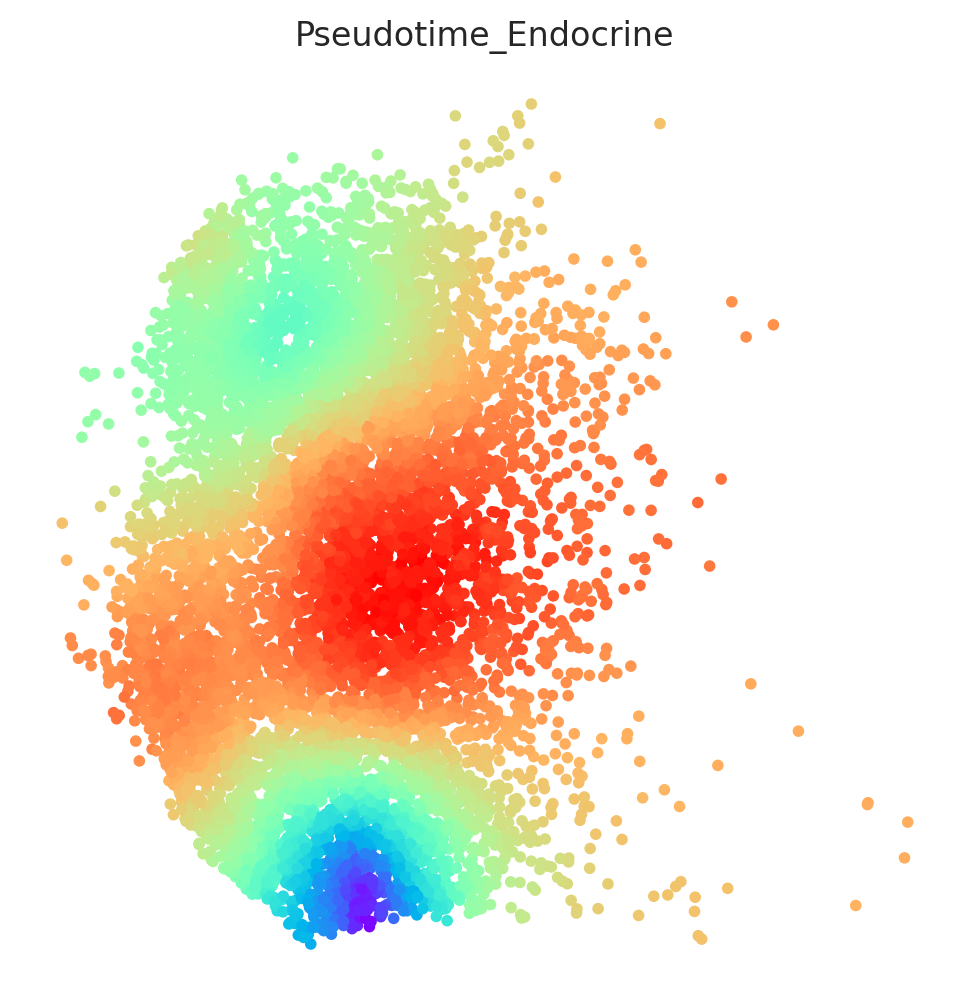

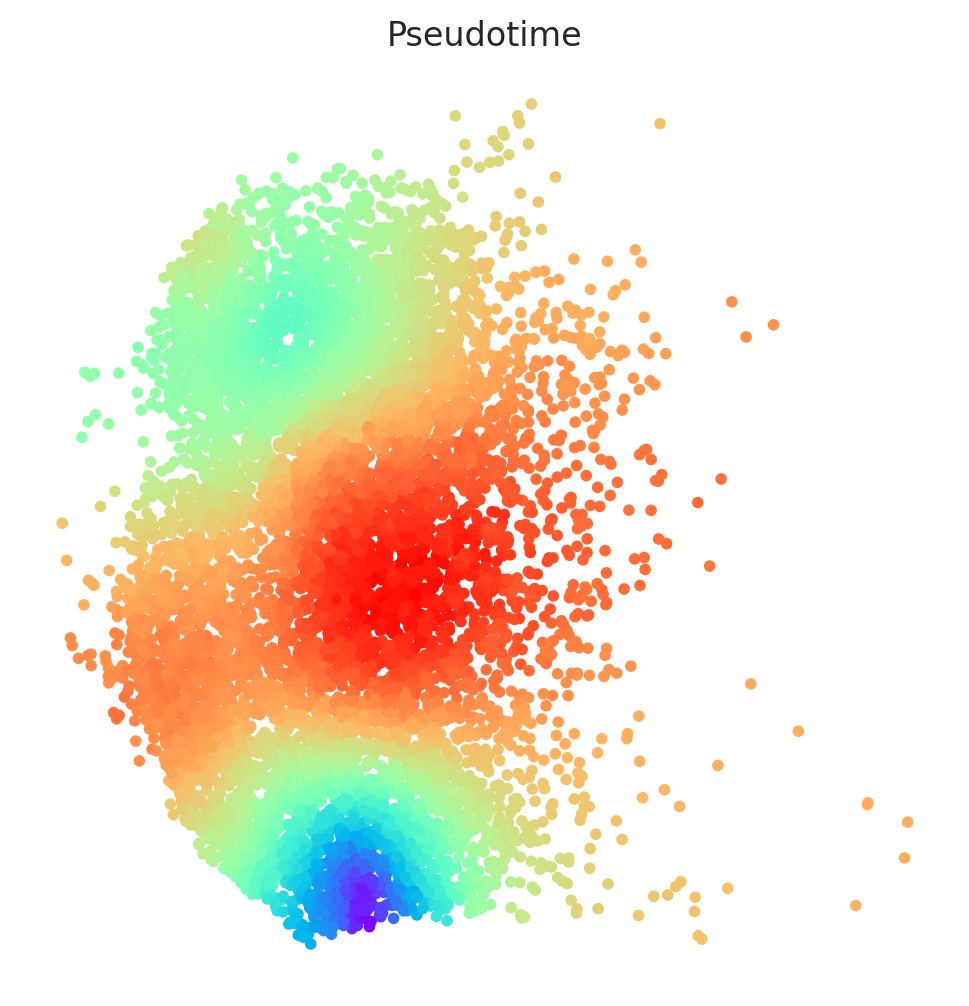

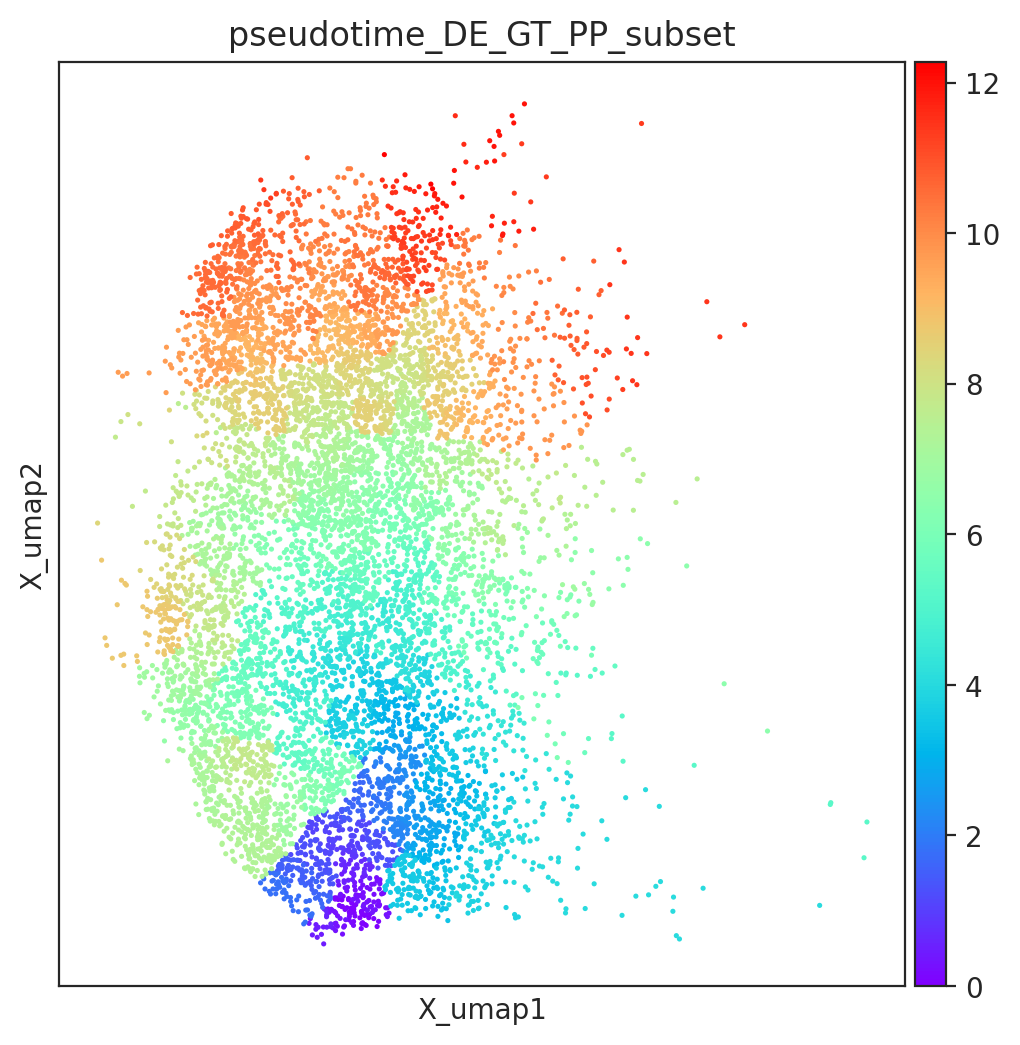

In [63]:
#Pseudotime
import celloracle as co
from celloracle.applications import Pseudotime_calculator

# Instantiate pseudotime object using oracle object.
pt = Pseudotime_calculator(oracle_object=oracle)

print("Clustering name: ", pt.cluster_column_name)
print("Cluster list", pt.cluster_list)

# Check data
pt.plot_cluster(fontsize=8)

    # Here, clusters can be classified into specific lineages
    
clusters_end_lineage = ["DE", 'PP', 'GT']
    
    # Make a dictionary
lineage_dictionary = {"Endocrine": clusters_end_lineage}
    
    # Input lineage information into pseudotime object
pt.set_lineage(lineage_dictionary=lineage_dictionary)
    
    # Visualize lineage information
pt.plot_lineages()
    
    # Estimated root cell name for each lineage
root_cells = {"Endocrine": "s2d1_TGGTGCATCTTAGCCC-1_paired"}
pt.set_root_cells(root_cells=root_cells)
    # Check root cell and lineage (it has to be close to an edge)
pt.plot_root_cells()
    #"s5d5_AAACATGCAAAGCTCC-1" <- other root cell for s5d5
      
    # Calculate pseudotime
pt.get_pseudotime_per_each_lineage()
    
    # Check results
pt.plot_pseudotime(cmap="rainbow")
      
    # Add calculated pseudotime data to the oracle object
oracle.adata.obs = pt.adata.obs
      
    # Visualize pseudotime
    
fig, ax = plt.subplots(figsize=[6,6])
sc.pl.embedding(adata=oracle.adata, basis=oracle.embedding_name, 
                      ax=ax, cmap="rainbow",
                      color=["pseudotime_DE_GT_PP_subset"])
      

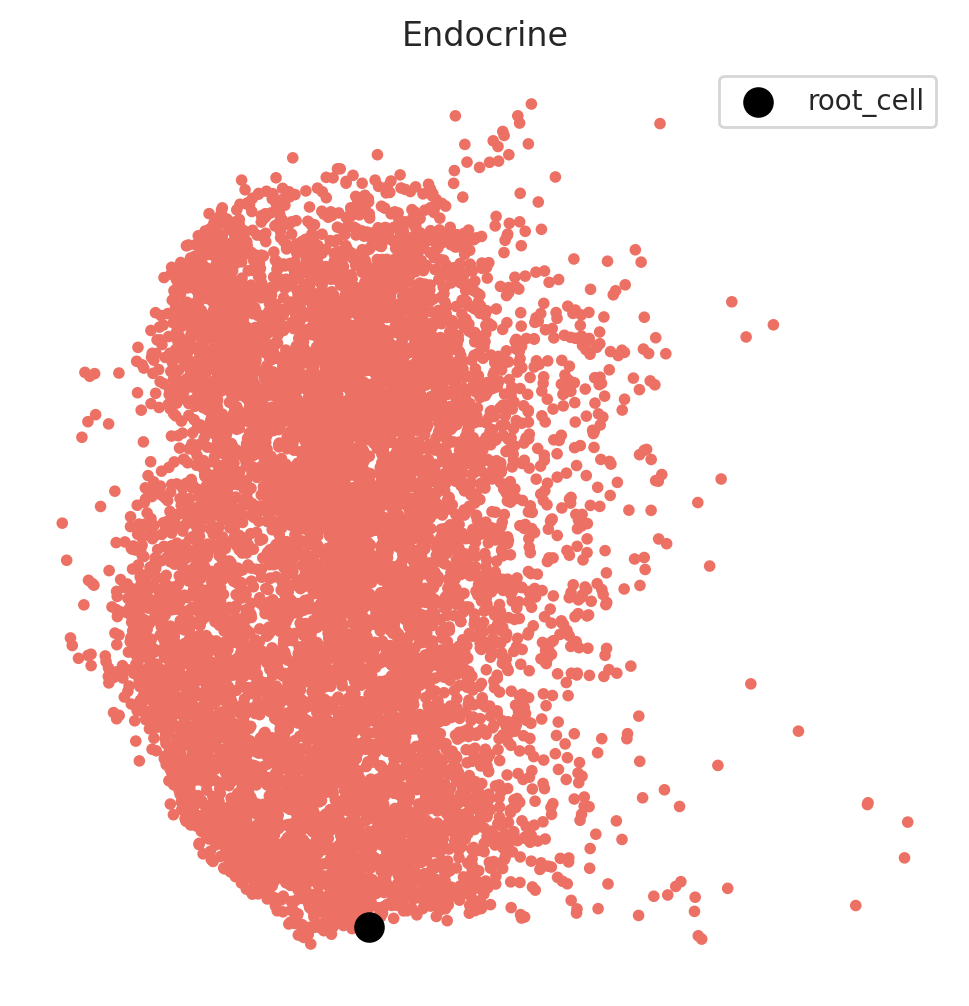

In [64]:
# Instantiate pseudotime object using oracle object.
pt = Pseudotime_calculator(oracle_object=oracle)
root_cells = {"Endocrine": "s2d1_TGGTGCATCTTAGCCC-1_paired"}
pt.set_root_cells(root_cells=root_cells)
pt.plot_root_cells()


In [65]:
# Save oracle object.
oracle.to_hdf5("checkpoints/celloracle/DT_Subset_DE_GT_PP.celloracle.oracle")


In [66]:
# Load file.
oracle = co.load_hdf5("checkpoints/celloracle/DT_Subset_DE_GT_PP.celloracle.oracle")


# GRN Calculations

In [67]:
#Get GRNs

#%%time
# Calculate GRN for each population in "louvain_annot" clustering unit.
# This step may take some time.(~30 minutes)
links = oracle.get_links(cluster_name_for_GRN_unit="celltype_DE_GT_PP_subset", alpha=10,
                         verbose_level=10)


  0%|          | 0/3 [00:00<?, ?it/s]

Inferring GRN for DE...


  0%|          | 0/2790 [00:00<?, ?it/s]

Inferring GRN for GT...


  0%|          | 0/2790 [00:00<?, ?it/s]

Inferring GRN for PP...


  0%|          | 0/2790 [00:00<?, ?it/s]

# Network preprocessing

In [1]:
#Filter network edges

links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)
plt.rcParams["figure.figsize"] = [9, 4.5]

links.plot_degree_distributions(plot_model=True) 
plt.rcParams["figure.figsize"] = [6, 4.5]

NameError: name 'links' is not defined

In [69]:
# Calculate network scores and Save Links object.
links.get_network_score()
links.merged_score.tail()
links.to_hdf5(file_path="checkpoints/celloracle/DT_Subset_DE_GT_PP.celloracle.links")


# Network analysis

In [6]:
# You can load files with the following command.
links = co.load_hdf5(file_path="checkpoints/celloracle/DT_Subset_DE_GT_PP.celloracle.links")

In [7]:
# Check cluster name
links.cluster


['DE', 'GT', 'PP']

In [8]:
# Save GRN as csv
net_scores = links.merged_score
net_scores.to_csv("outputs/celloracle_tables/Network_Scores_per_Cluster_DT_Subset_DE_GT_PP_paper.csv")
#Table S8

## Top gene centrality score by cell state Fig. S15D

In [9]:
Centrality_all = pd.read_csv("outputs/celloracle_tables/Network_Scores_per_Cluster_DT_Subset_DE_GT_PP_paper.csv").rename(columns={"Unnamed: 0": "gene"})
Centrality_all.head(1)


,gene,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
0,TCF12,141,0.193681,0,0.0,141,0.193681,0.0,0.984807,DE


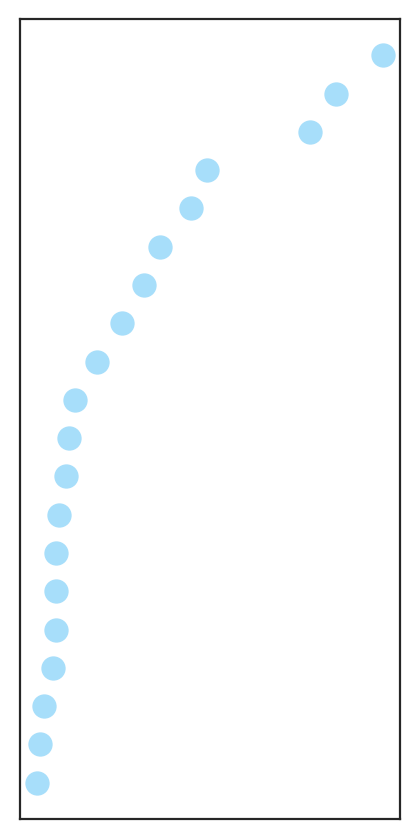

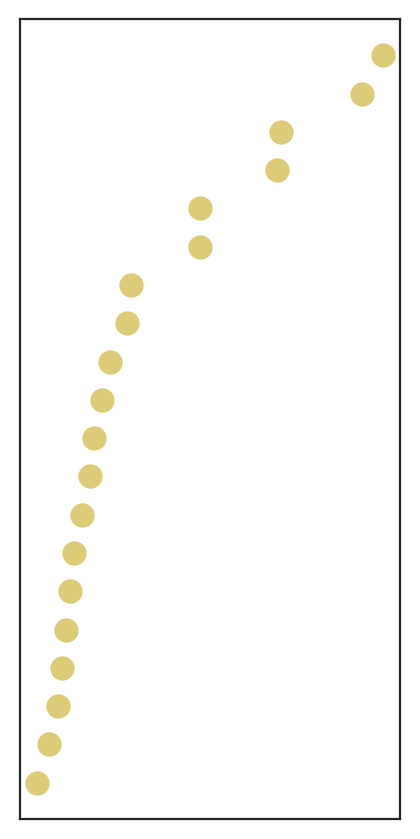

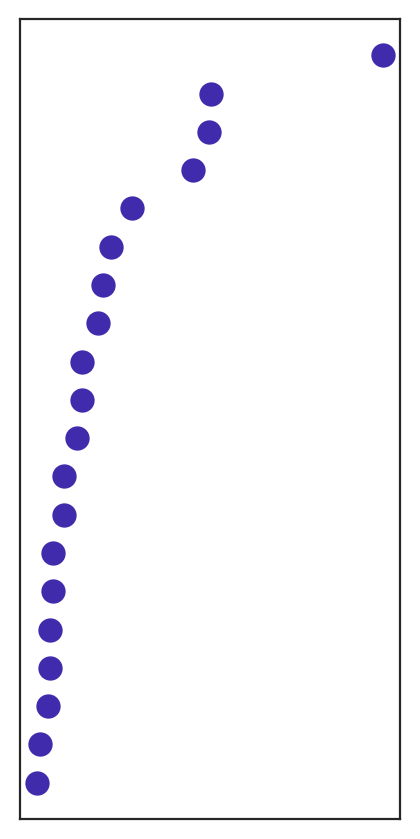

Saved clean dot plots to: outputs/celloracle_figures/DT_Subset_DE_GT_PP


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Build `top` (top 20 genes per cluster by degree_centrality_all) ---
df = Centrality_all[["gene", "degree_centrality_all", "cluster"]].copy()
df = df.dropna(subset=["gene", "degree_centrality_all", "cluster"])
df["cluster"] = df["cluster"].astype(str).str.strip()
df["gene"] = df["gene"].astype(str).str.strip()
df["degree_centrality_all"] = pd.to_numeric(df["degree_centrality_all"], errors="coerce")
df = df.dropna(subset=["degree_centrality_all"])

# If duplicates exist, keep max per (cluster,gene)
df = df.groupby(["cluster", "gene"], as_index=False)["degree_centrality_all"].max()

top_n = 20
top = (
    df.sort_values(["cluster", "degree_centrality_all"], ascending=[True, False])
      .groupby("cluster", group_keys=False)
      .head(top_n)
)

# --- Palette ---
pal = {
    "Mesench.": "#ffbd00",
    "UE": "#EE3377",
    "DE": "#a7defa",
    "GT": "#DDCC77",
    "PP": "#402bad",
    "Exocrine": "#117733",
    "eEP": "#fcb686",
    "lEP": "#cd853f",
    "Alpha": "#f55e07",
    "Delta": "#7d9e31",
    "EC": "#015f94",
    "Beta": "#ba0c2f",
    "Beta-EC": "#b867bf",
}

# --- Plot (dots), no labels, keep box, save tightly (no white ribbon) ---
save_folder = "outputs/celloracle_figures/DT_Subset_DE_GT_PP"
os.makedirs(save_folder, exist_ok=True)

for cluster, sub in top.groupby("cluster"):
    sub = sub.sort_values("degree_centrality_all", ascending=False).reset_index(drop=True)
    sub["rank"] = sub.index + 1

    fig, ax = plt.subplots(figsize=(1.9, 4))
    cluster_color = pal.get(cluster, "#9e9e9e")

    ax.scatter(sub["degree_centrality_all"], sub["rank"], s=60, marker="o", c=cluster_color)
    ax.invert_yaxis()

    ax.set_title("")
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("")

    out_png = os.path.join(save_folder, f"rank_top{top_n}_{cluster}_dots_clean.png")

    # Fill the whole canvas with the axes (box) and save with zero padding
    ax.set_position([0, 0, 1, 1])
    fig.savefig(out_png, dpi=600, bbox_inches="tight", pad_inches=0)

    plt.show()
    plt.close(fig)

print(f"Saved clean dot plots to: {save_folder}")


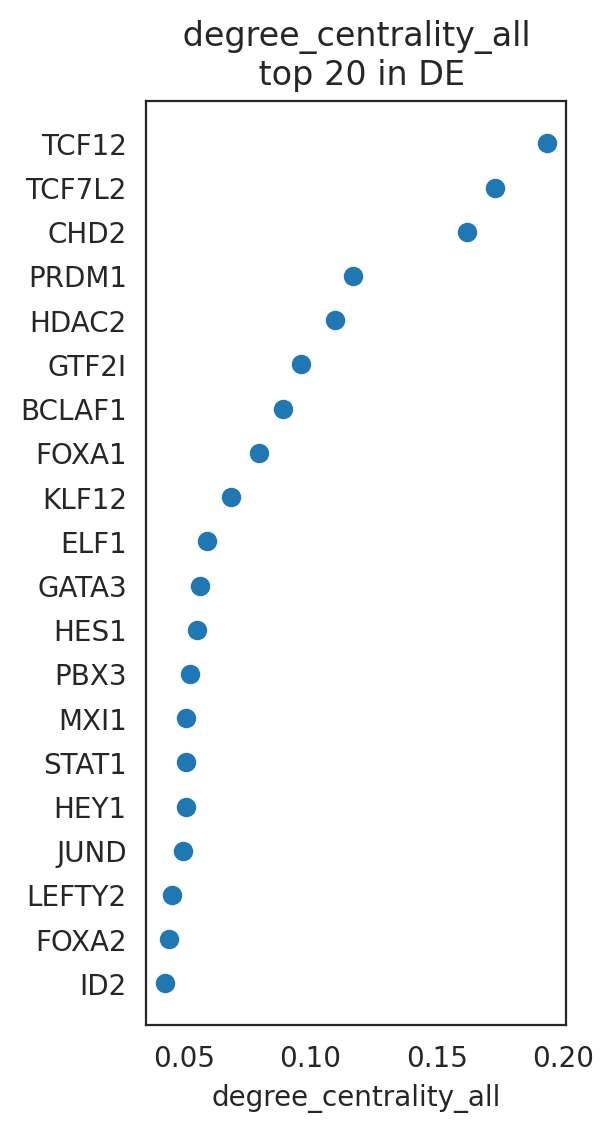

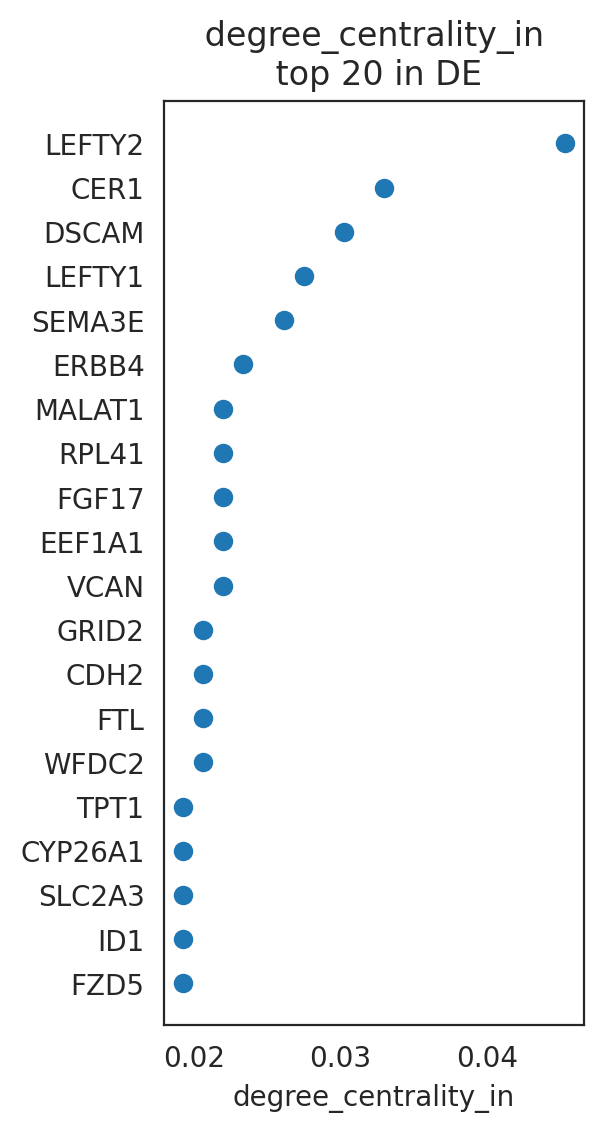

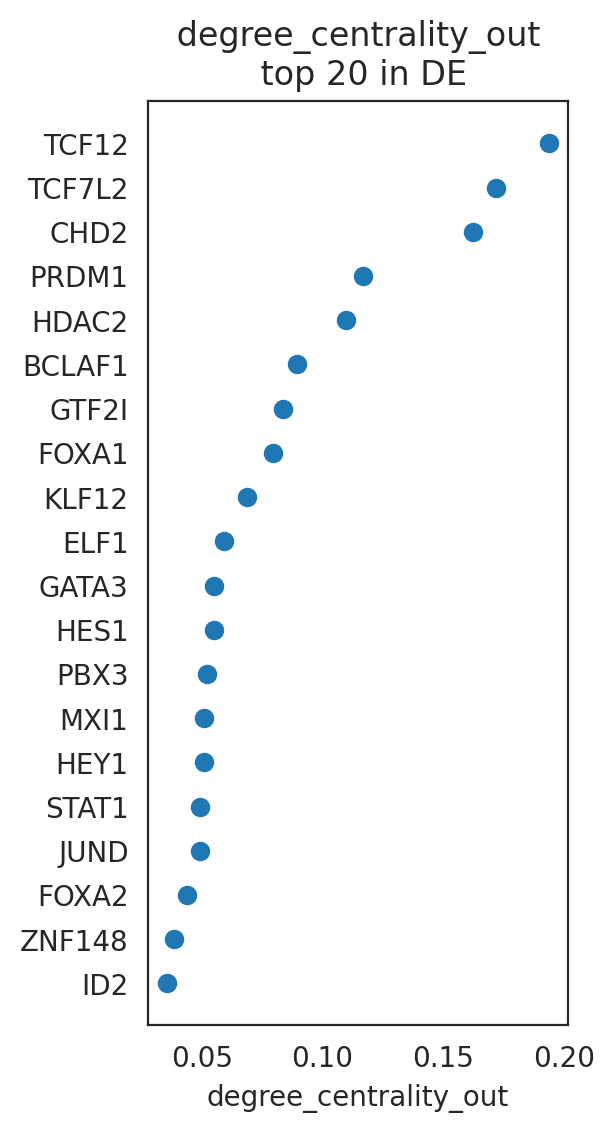

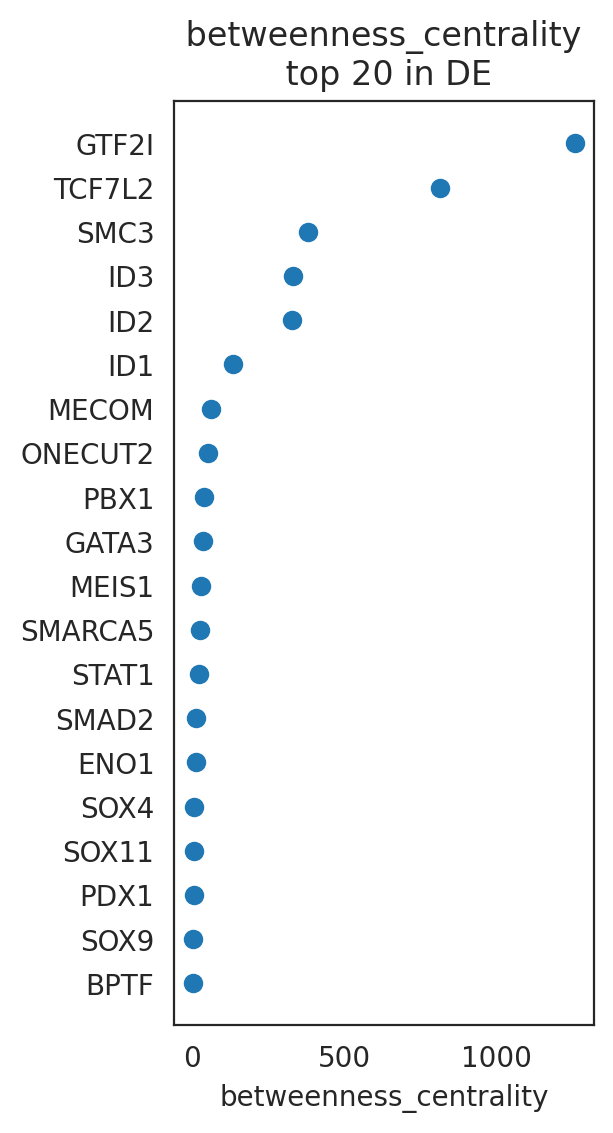

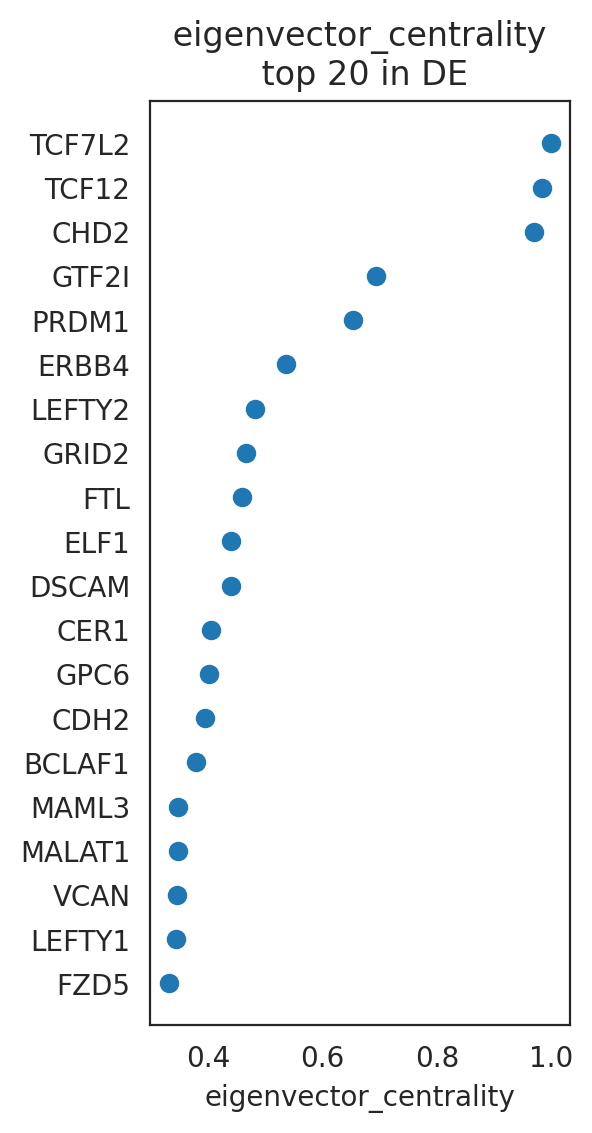

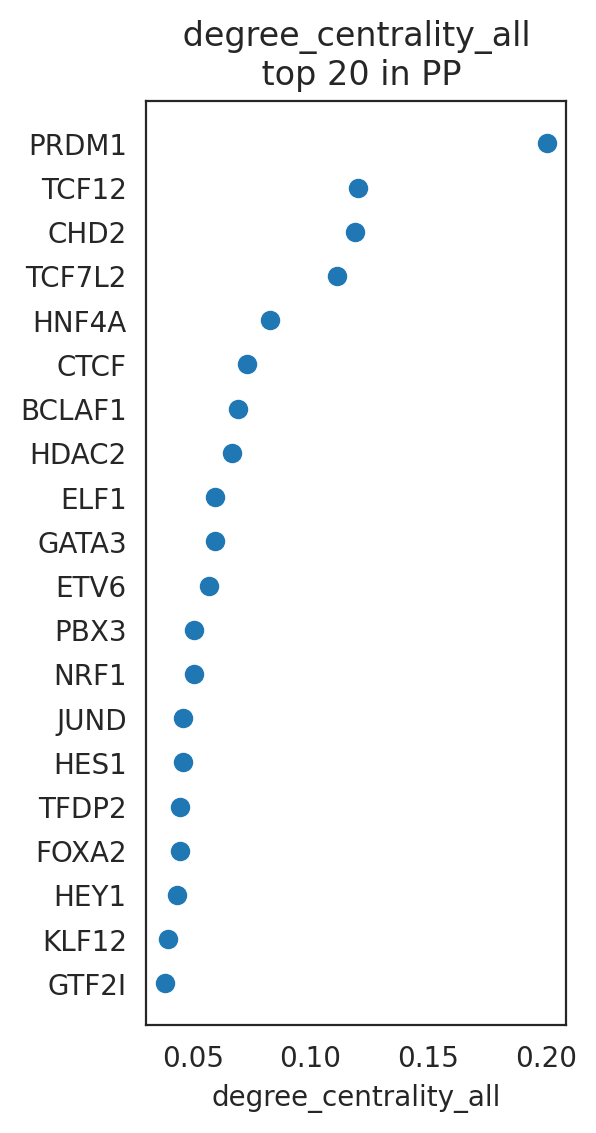

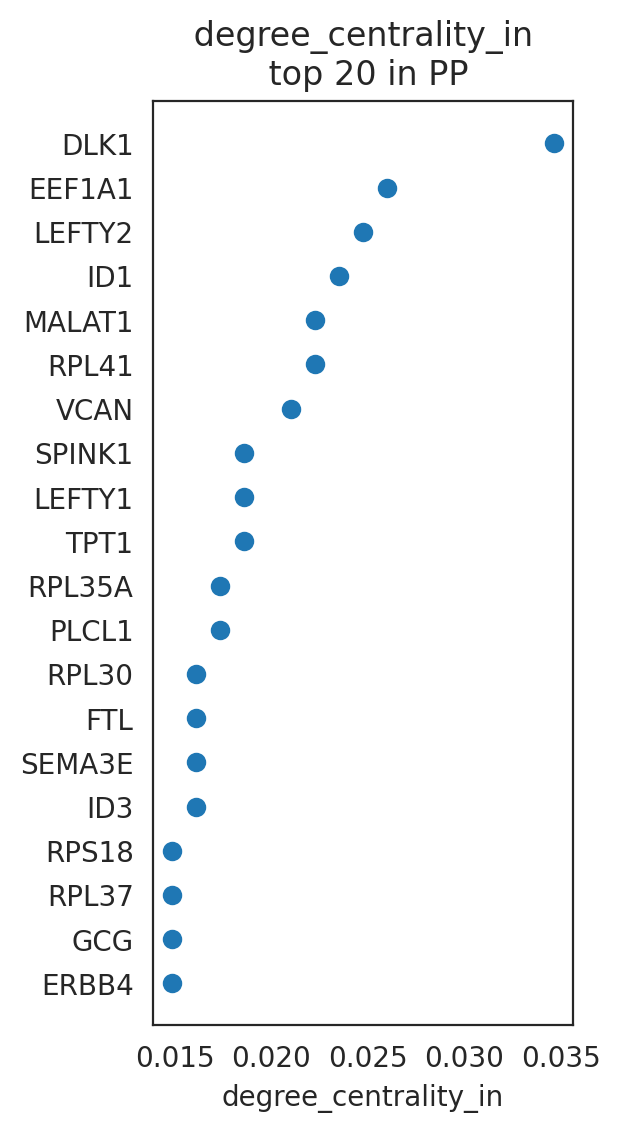

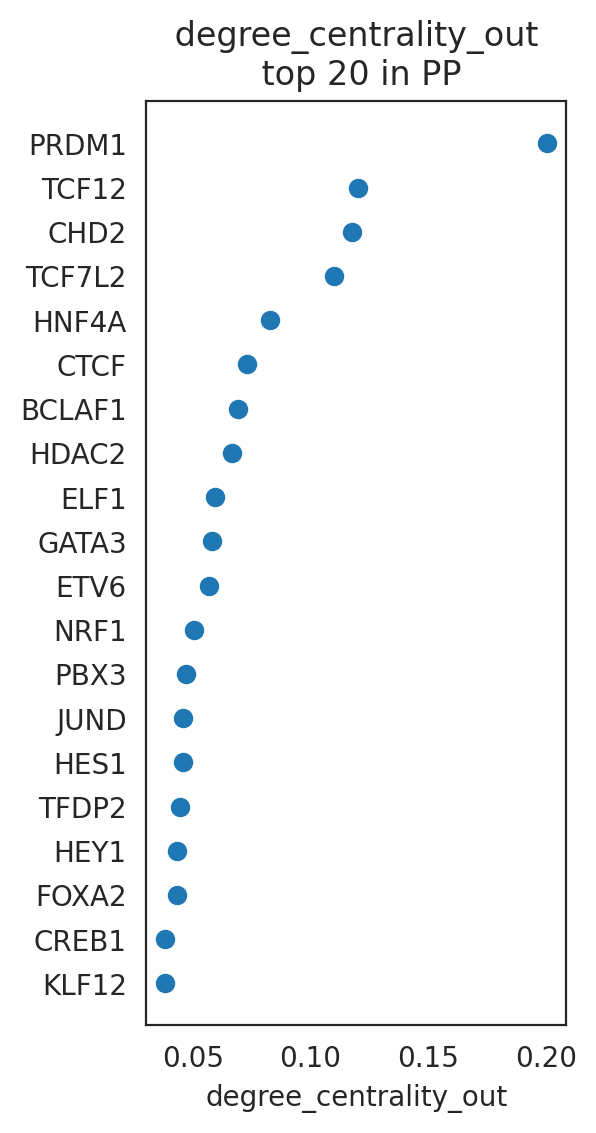

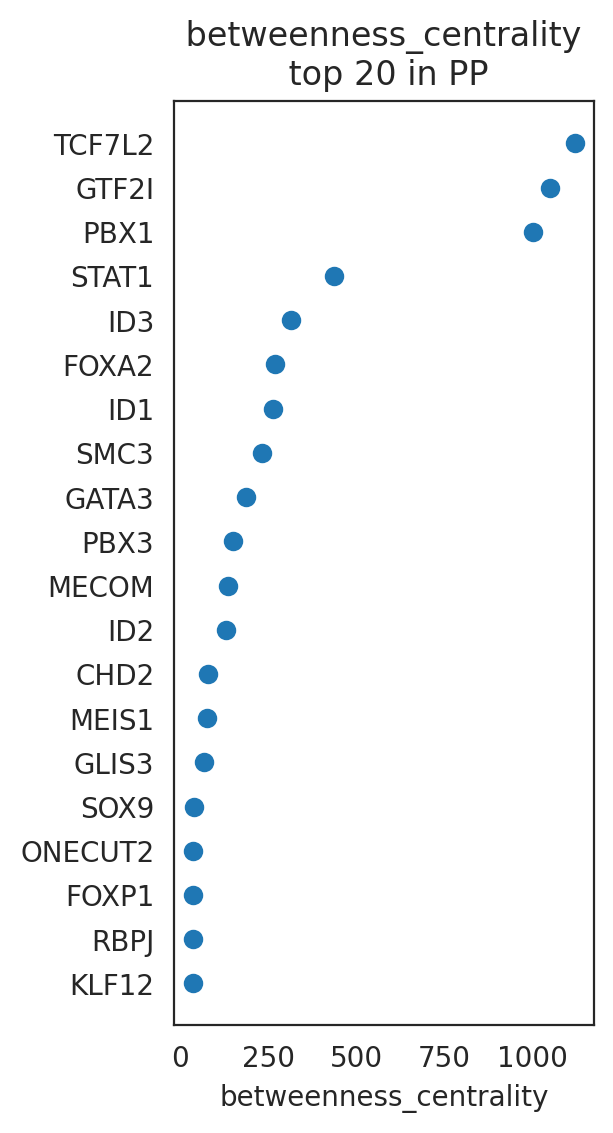

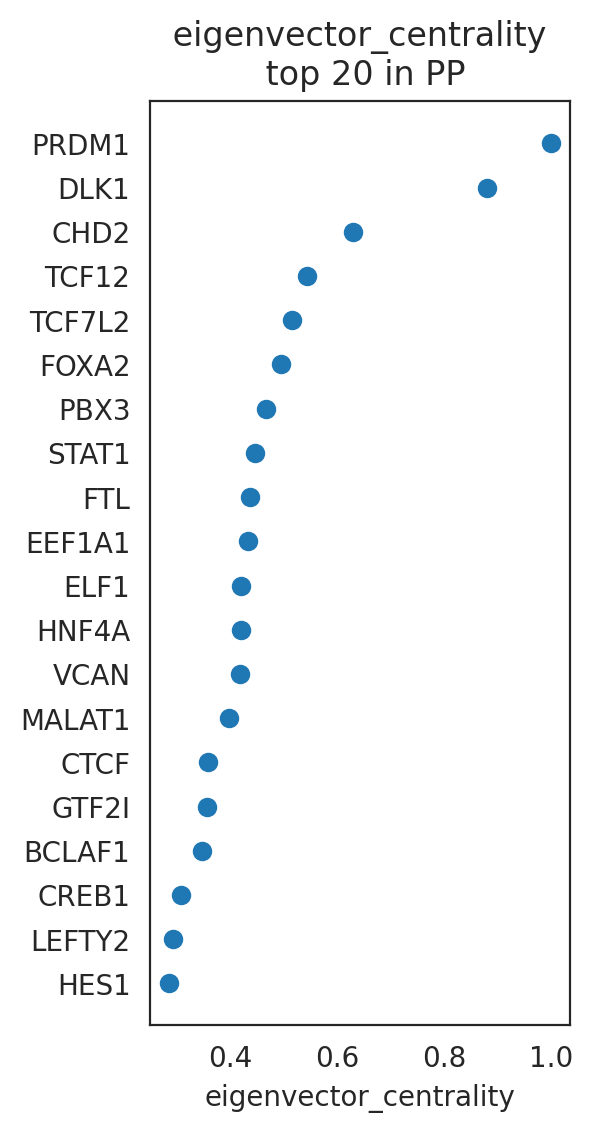

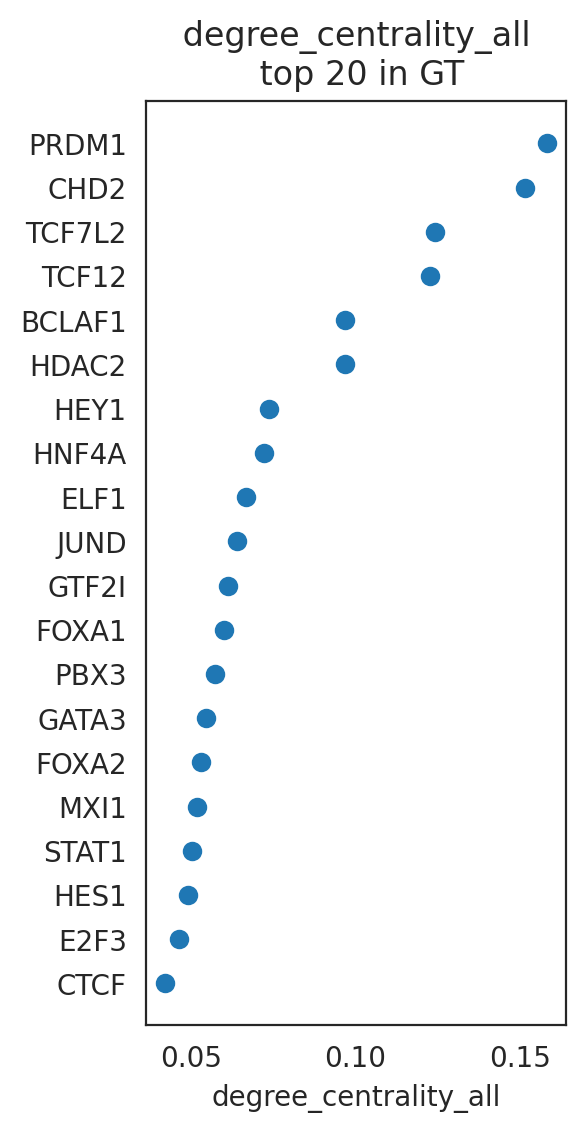

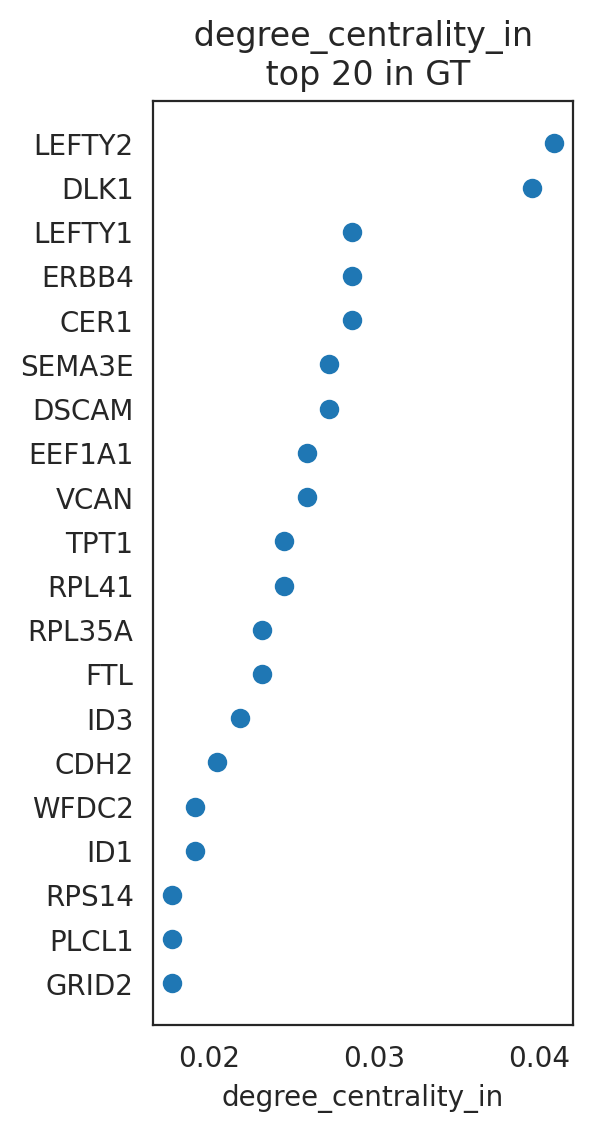

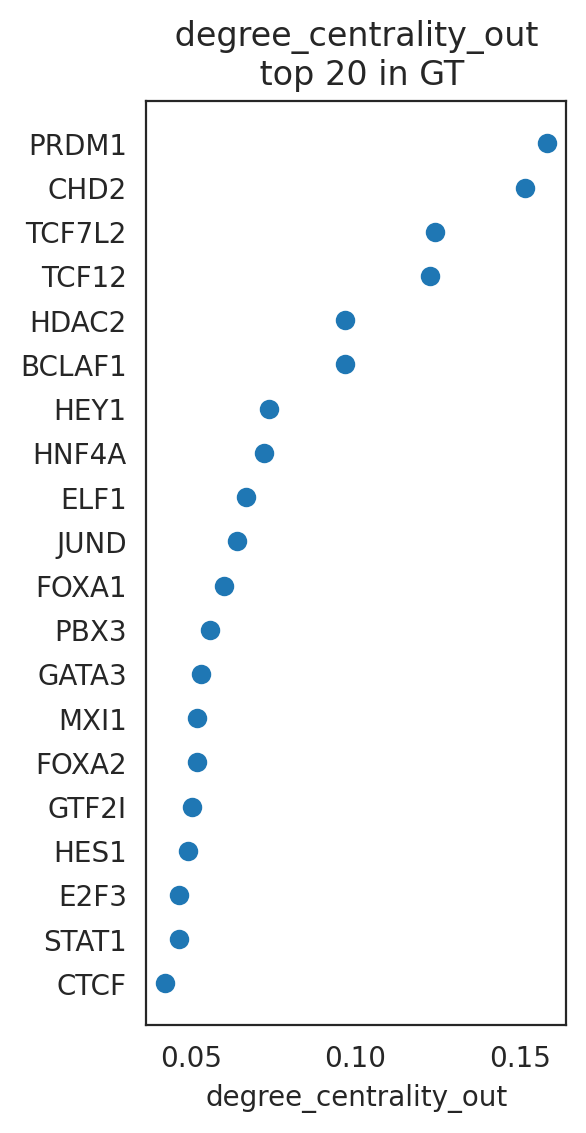

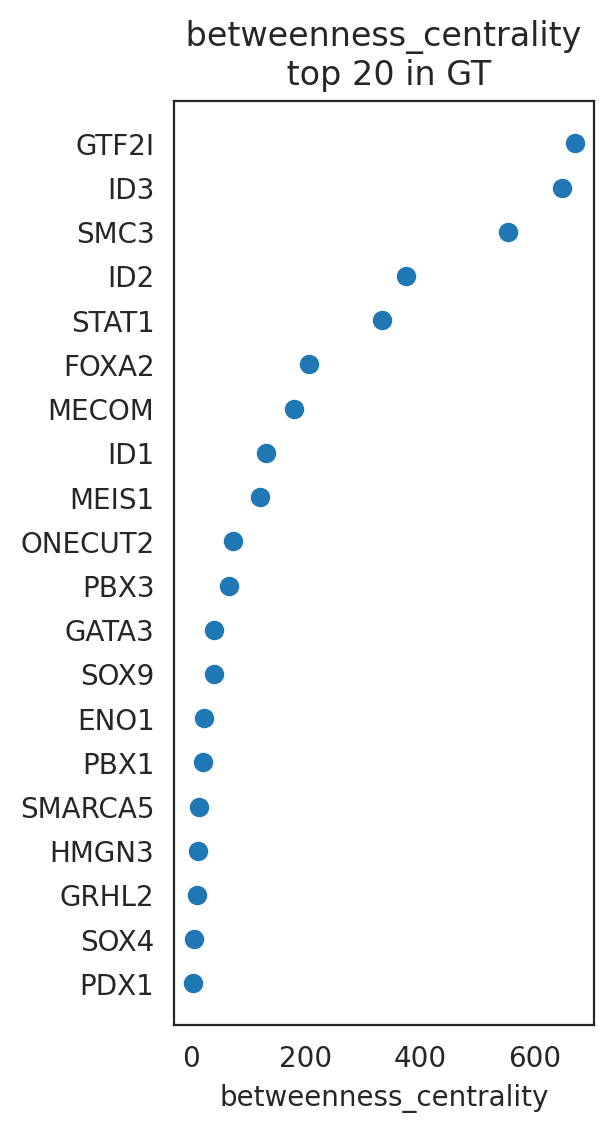

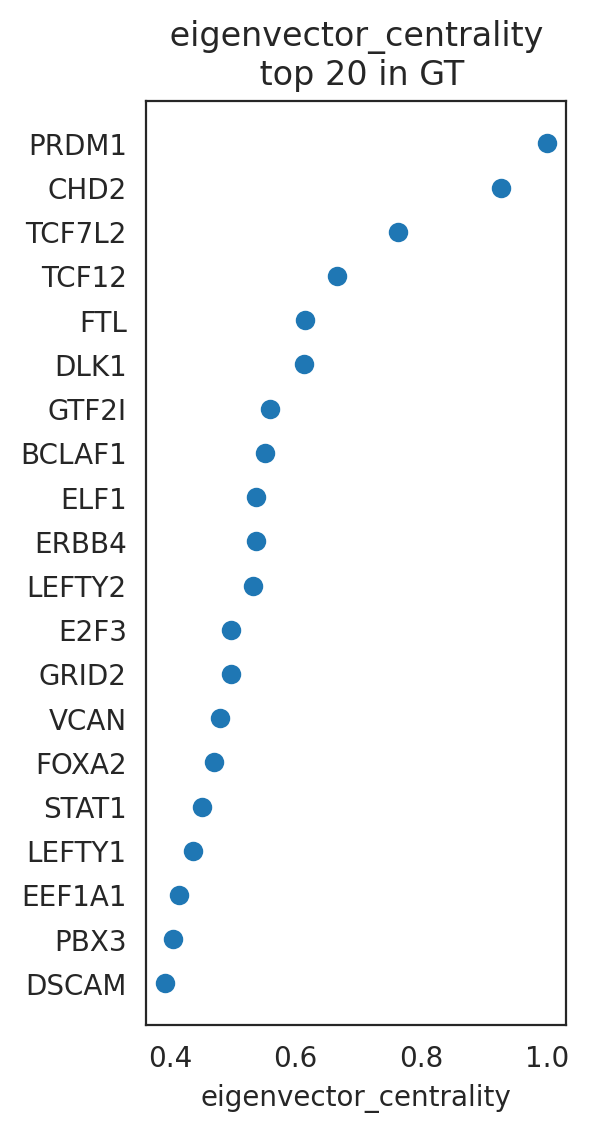

In [11]:
# Visualize top n-th genes with high scores.
plt.rcParams["figure.figsize"] = [6, 6]
links.plot_scores_as_rank(cluster="DE", 
                          n_gene=20, save=f"{save_folder}/ranked_score")
links.plot_scores_as_rank(cluster="PP", 
                          n_gene=20, save=f"{save_folder}/ranked_score")
links.plot_scores_as_rank(cluster="GT", 
                          n_gene=20, save=f"{save_folder}/ranked_score")


## Gene centrality score by gene and cell state Fig. 3F

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_gene_centrality_across_clusters_equal_air(
    df, gene_of_interest, pal,
    cluster_order=None,
    save_folder="outputs/celloracle_figures/DT_Subset_DE_GT_PP",
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
):
    os.makedirs(save_folder, exist_ok=True)

    g = df[df["gene"] == gene_of_interest].copy()
    if g.empty:
        raise ValueError(f"{gene_of_interest} not found (check spelling/case).")

    # enforce custom order (e.g. DE, GT, PP)
    if cluster_order is not None:
        order_map = {c: i for i, c in enumerate(cluster_order)}
        g["order"] = g["cluster"].map(order_map).fillna(len(order_map) + 999).astype(int)
        g = g.sort_values(["order", "cluster"]).reset_index(drop=True)
    else:
        g = g.sort_values("degree_centrality_all", ascending=False).reset_index(drop=True)

    n = g.shape[0]

    # (Optional but usually nicer when swapping axes): make width scale with n, keep height fixed-ish
    height_in = width_in
    width_in = max(row_height_in * n, 0.03)

    # Dot diameter fixed at 0.1"
    D_pts = dot_diameter_in * 72.0
    s = np.pi * (D_pts / 2.0) ** 2  # area in pt^2

    x = np.arange(n)  # cluster index on X
    y = g["degree_centrality_all"].values  # centrality on Y
    colors = g["cluster"].map(pal).fillna("#9e9e9e").values

    fig, ax = plt.subplots(figsize=(width_in, height_in), dpi=dpi)

    # ---- SWAP: (x,y) becomes (index, centrality) ----
    ax.scatter(x, y, s=s, marker="o", c=colors)

    # Minimal axes (keep box)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Make the axes fill the figure so there's no ribbon
    ax.set_position([0, 0, 1, 1])

    # Base limits (before adding inch-based padding)
    ymin = float(np.min(y))
    ymax = float(np.max(y))
    if ymax == ymin:
        ymax = ymin + 1e-6

    # ---- PRINT min/max for PPT ----
    print(f"{gene_of_interest} degree_centrality_all min = {ymin:.6g}")
    print(f"{gene_of_interest} degree_centrality_all max = {ymax:.6g}")

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(ymin, ymax)

    # --- Compute EXACT padding in data units for equal air in inches ---
    clear_in = (dot_diameter_in / 2.0) + air_in   # 0.05" + 0.01" = 0.06"
    clear_px = clear_in * dpi

    fig.canvas.draw()  # ensure transforms are ready

    # x padding in data units (at mid y)
    y_mid = (ymin + ymax) / 2
    p0 = ax.transData.transform((-0.5, y_mid))
    x1, _ = ax.transData.inverted().transform((p0[0] + clear_px, p0[1]))
    pad_x = x1 - (-0.5)

    # y padding in data units (at mid x)
    x_mid = (n - 1) / 2 if n > 1 else 0
    p0y = ax.transData.transform((x_mid, ymin))
    _, y1 = ax.transData.inverted().transform((p0y[0], p0y[1] + clear_px))
    pad_y = y1 - ymin

    ax.set_xlim(-0.001 - pad_x, (n - 0.999) + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    out_png = os.path.join(save_folder, f"{gene_of_interest}_degree_centrality_all.png")
    fig.savefig(out_png, dpi=dpi, pad_inches=0)  # keep symmetry

    plt.show()
    plt.close(fig)

    # Return path 
    return out_png


SMC3 degree_centrality_all min = 0.0123762
SMC3 degree_centrality_all max = 0.0384615


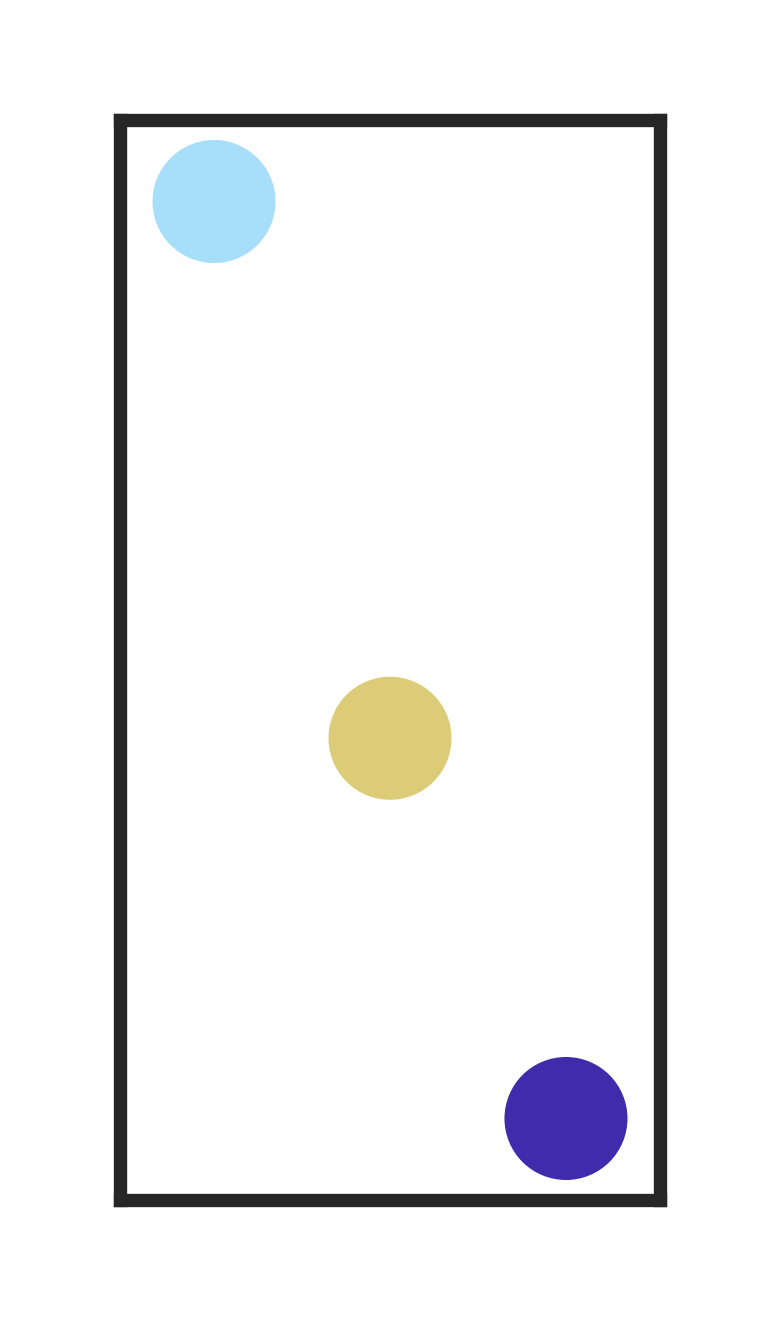

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/SMC3_degree_centrality_all.png


In [10]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="SMC3",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

NR2C2 degree_centrality_all min = 0.010989
NR2C2 degree_centrality_all max = 0.0148515


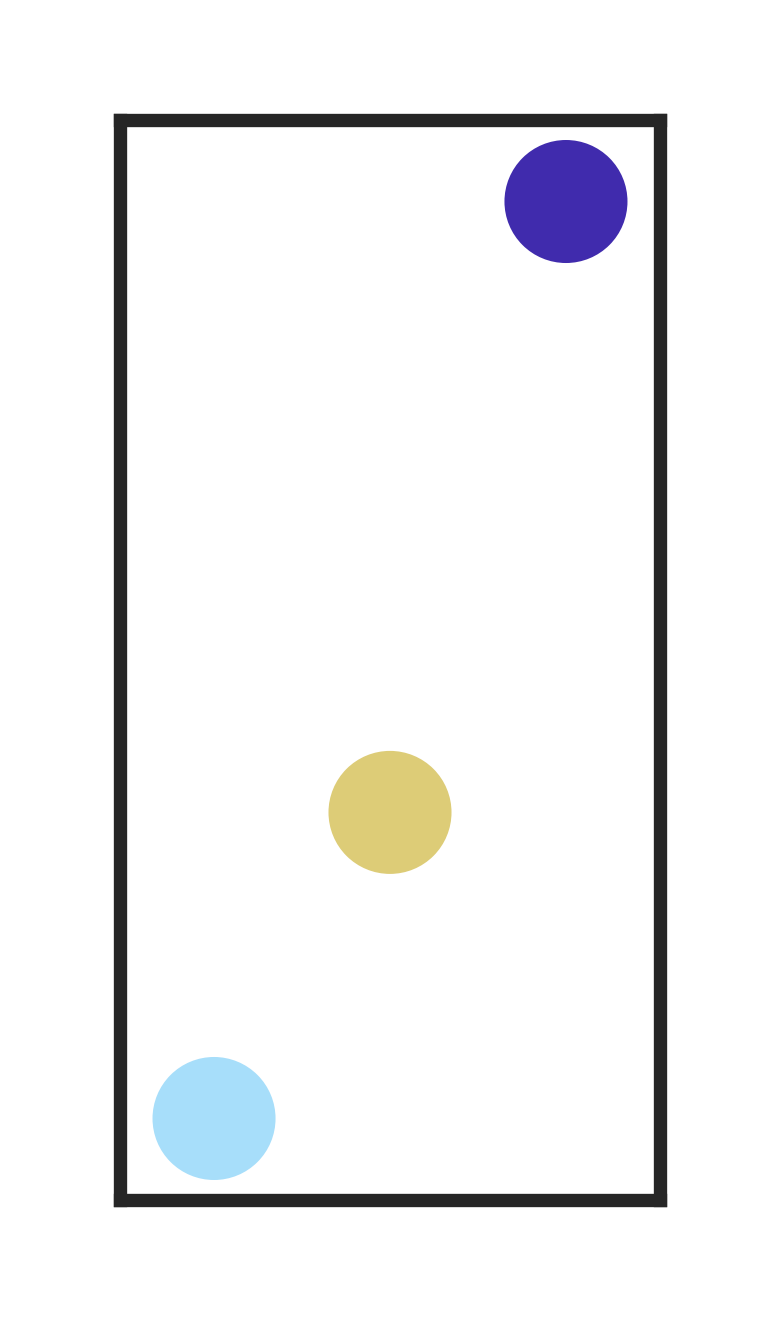

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/NR2C2_degree_centrality_all.png


In [11]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="NR2C2",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

BCLAF1 degree_centrality_all min = 0.0693069
BCLAF1 degree_centrality_all max = 0.0968622


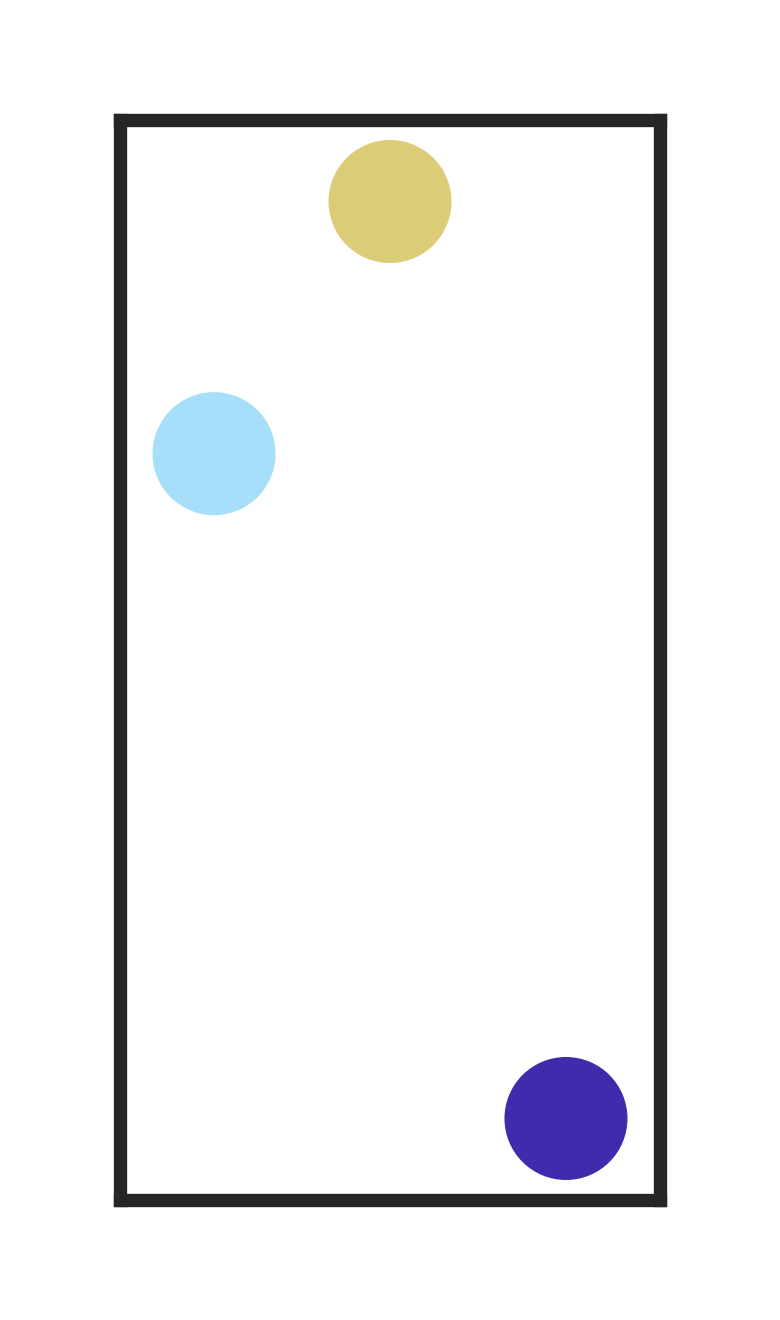

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/BCLAF1_degree_centrality_all.png


In [12]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="BCLAF1",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

ID3 degree_centrality_all min = 0.0233516
ID3 degree_centrality_all max = 0.0354707


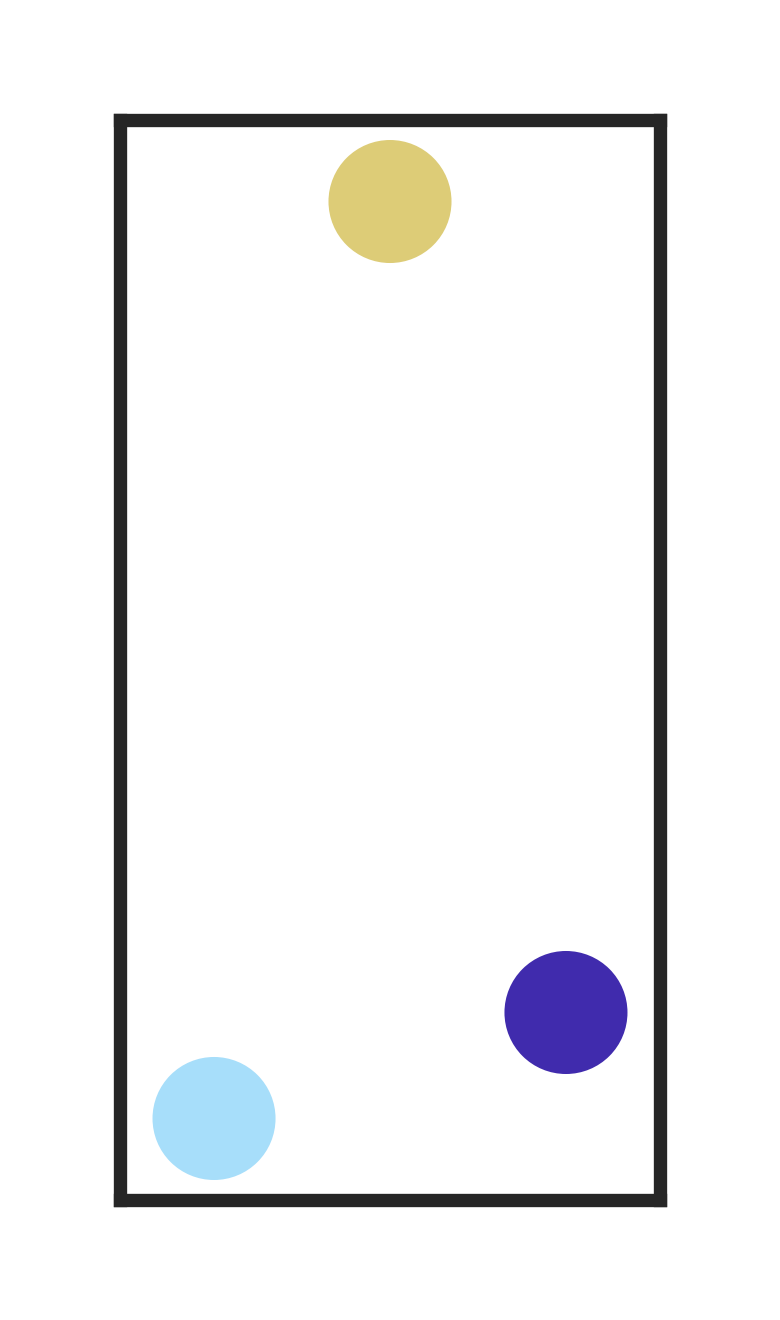

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/ID3_degree_centrality_all.png


In [13]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="ID3",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

ID2 degree_centrality_all min = 0.0210396
ID2 degree_centrality_all max = 0.0425824


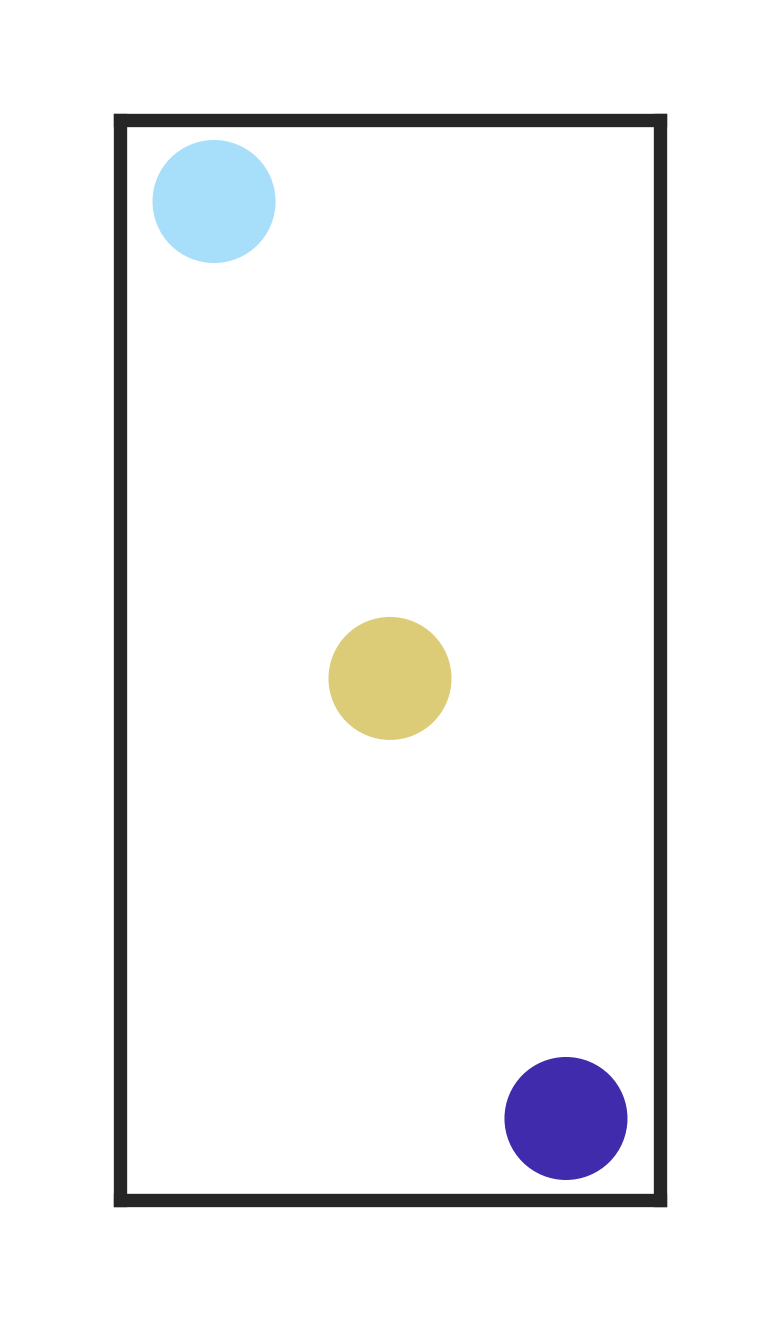

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/ID2_degree_centrality_all.png


In [14]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="ID2",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

POU2F1 degree_centrality_all min = 0.00371287
POU2F1 degree_centrality_all max = 0.00412088


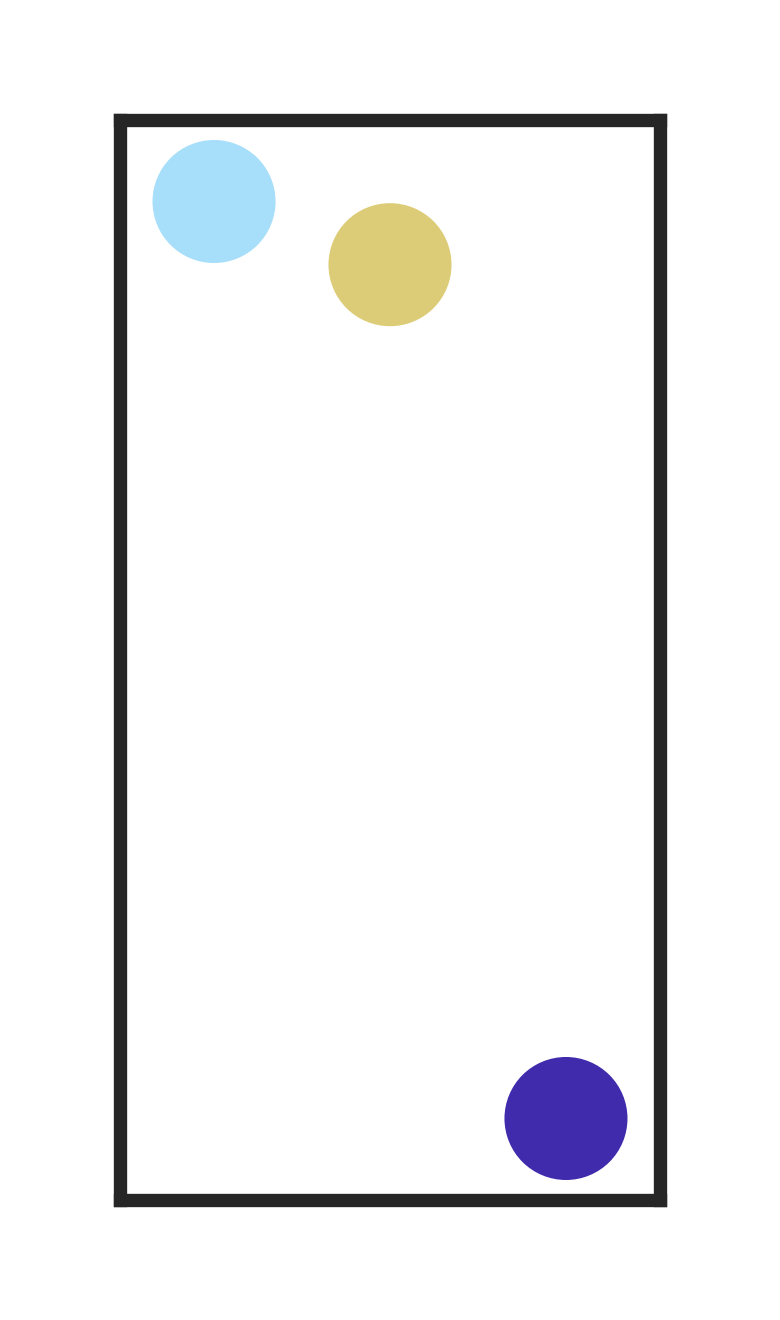

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/POU2F1_degree_centrality_all.png


In [15]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="POU2F1",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

GATA4 degree_centrality_all min = 0.0160891
GATA4 degree_centrality_all max = 0.0204638


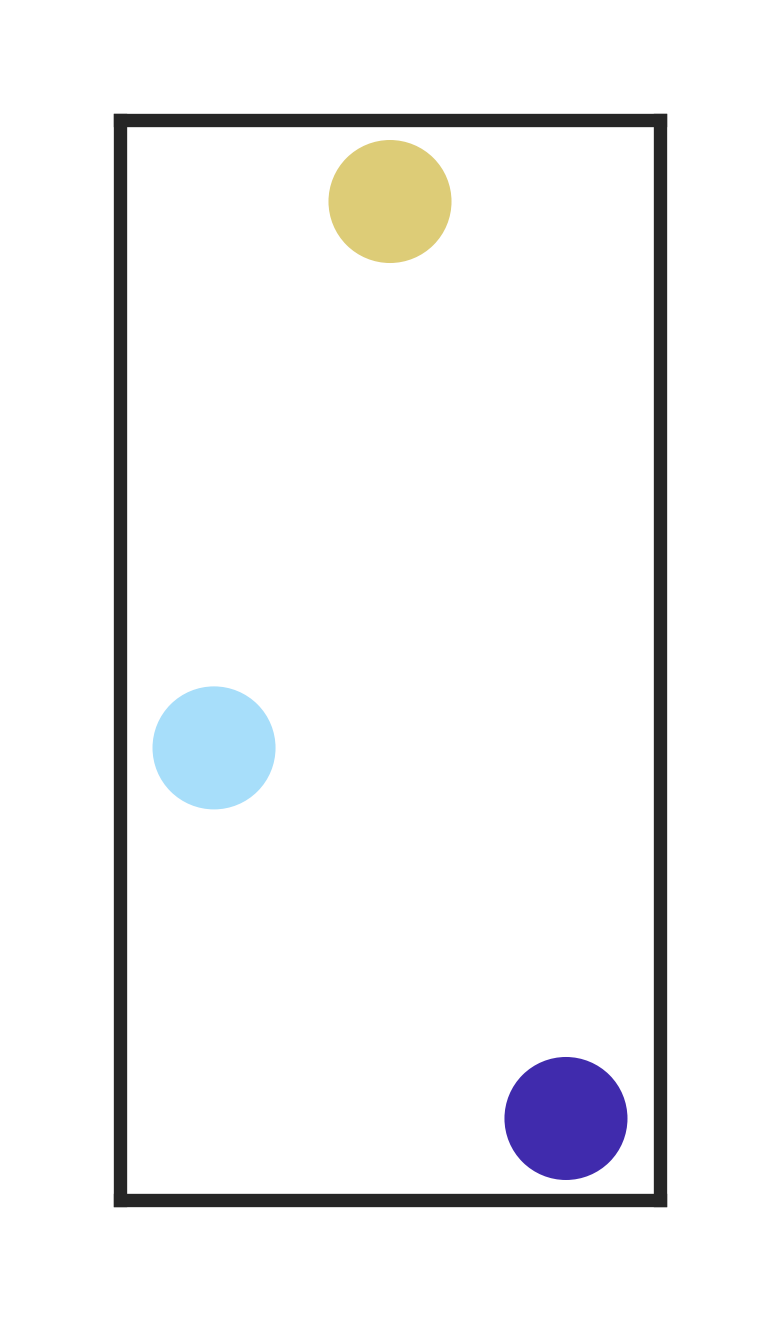

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/GATA4_degree_centrality_all.png


In [16]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="GATA4",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

ID4 degree_centrality_all min = 0.00371287
ID4 degree_centrality_all max = 0.00549451


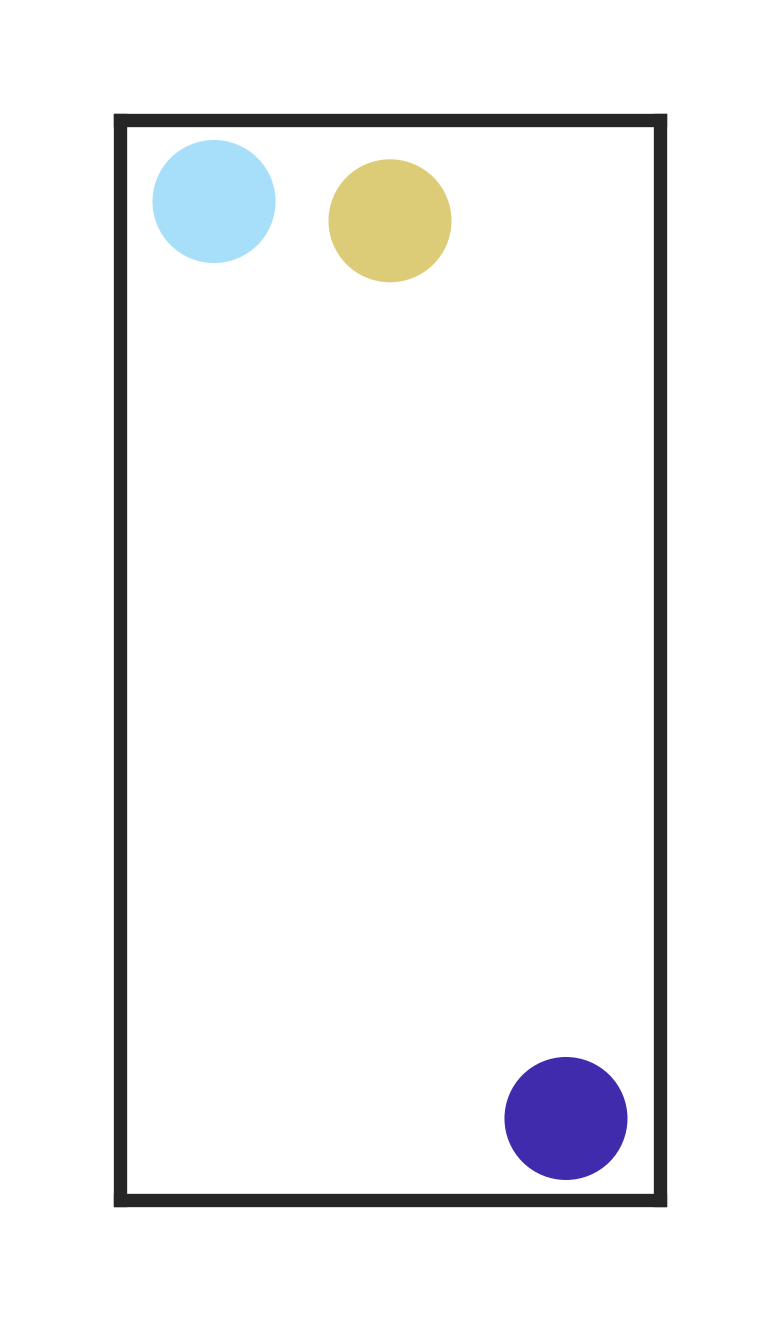

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/ID4_degree_centrality_all.png


In [17]:
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="ID4",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

FOXA1 degree_centrality_all min = 0.0346535
FOXA1 degree_centrality_all max = 0.0796703


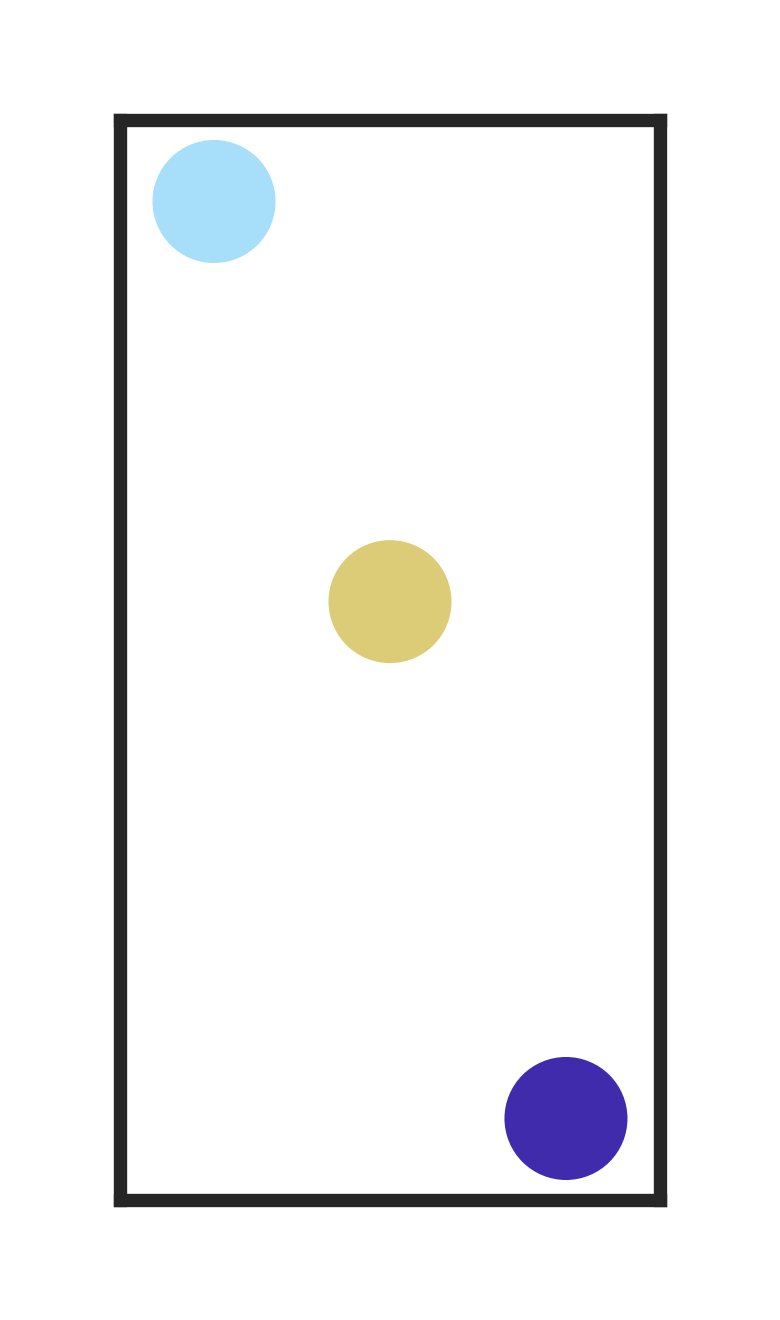

Saved: outputs/celloracle_figures/DT_Subset_DE_GT_PP/FOXA1_degree_centrality_all.png


In [18]:
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="FOXA1",
    pal=pal,
    cluster_order=["DE", "GT", "PP"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

ID4


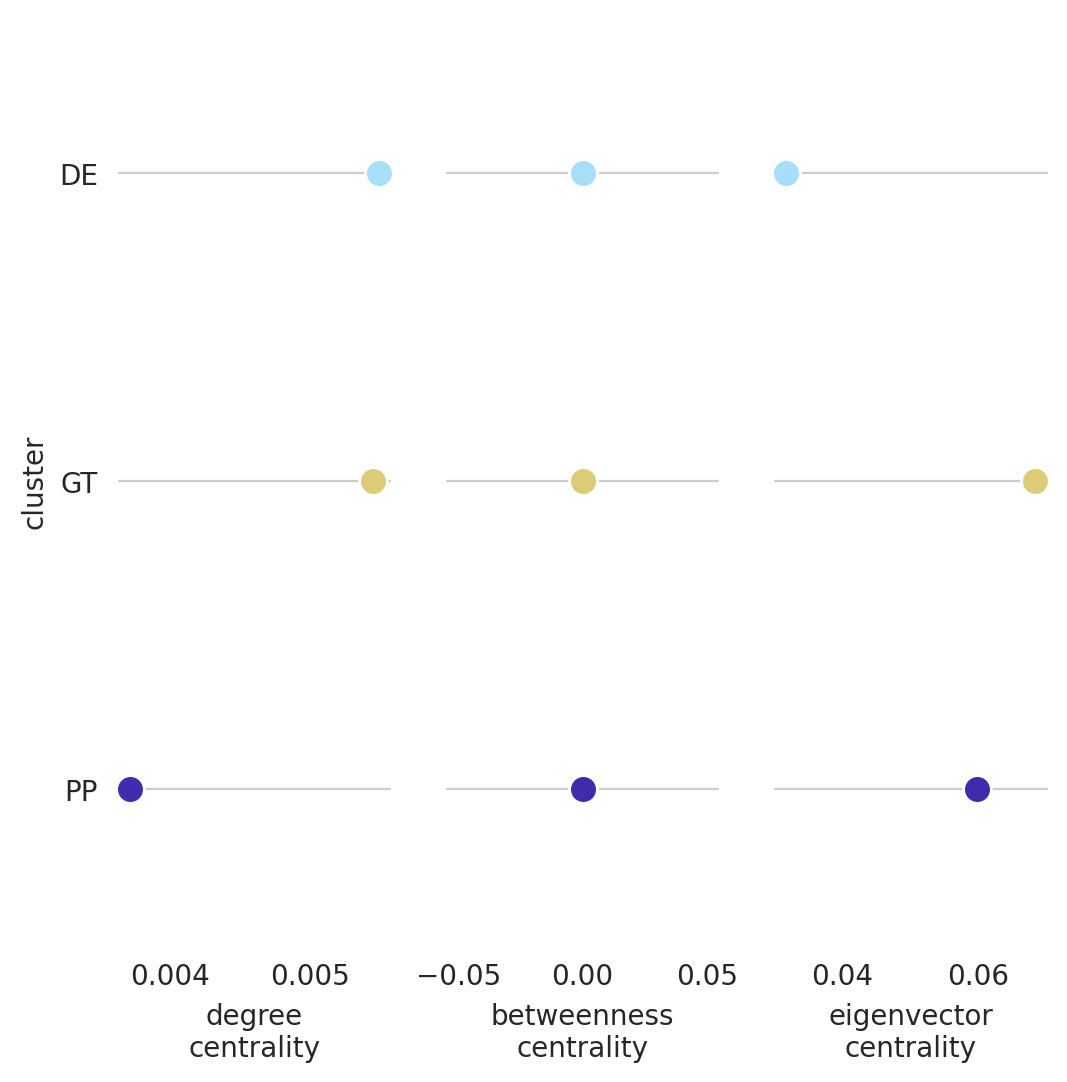

GATA4


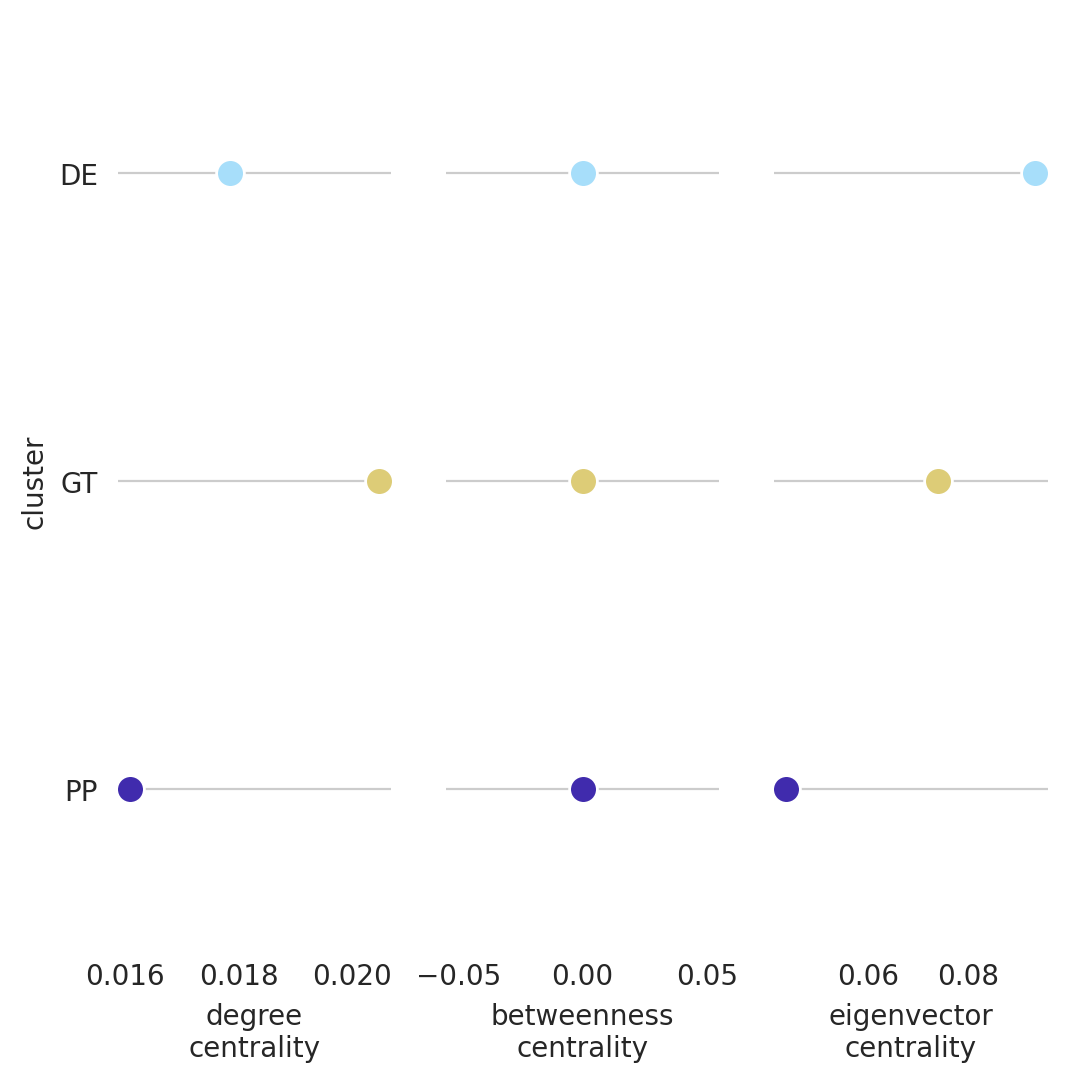

In [21]:
# Visualize X network score dynamics
links.plot_score_per_cluster(goi="ID4", save=f"{save_folder}/network_score_per_gene/")
links.plot_score_per_cluster(goi="GATA4", save=f"{save_folder}/network_score_per_gene/")


SOX9


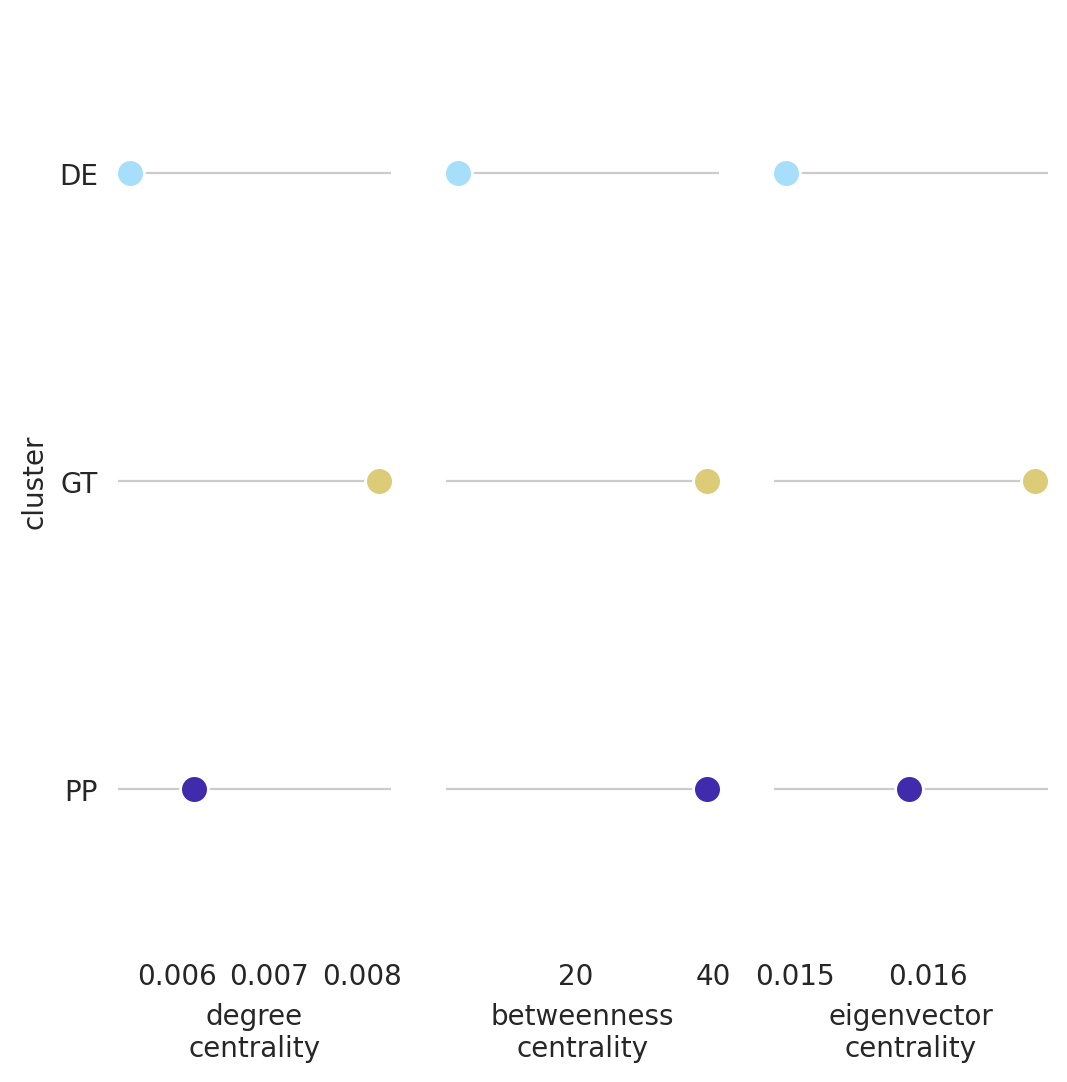

SOX17


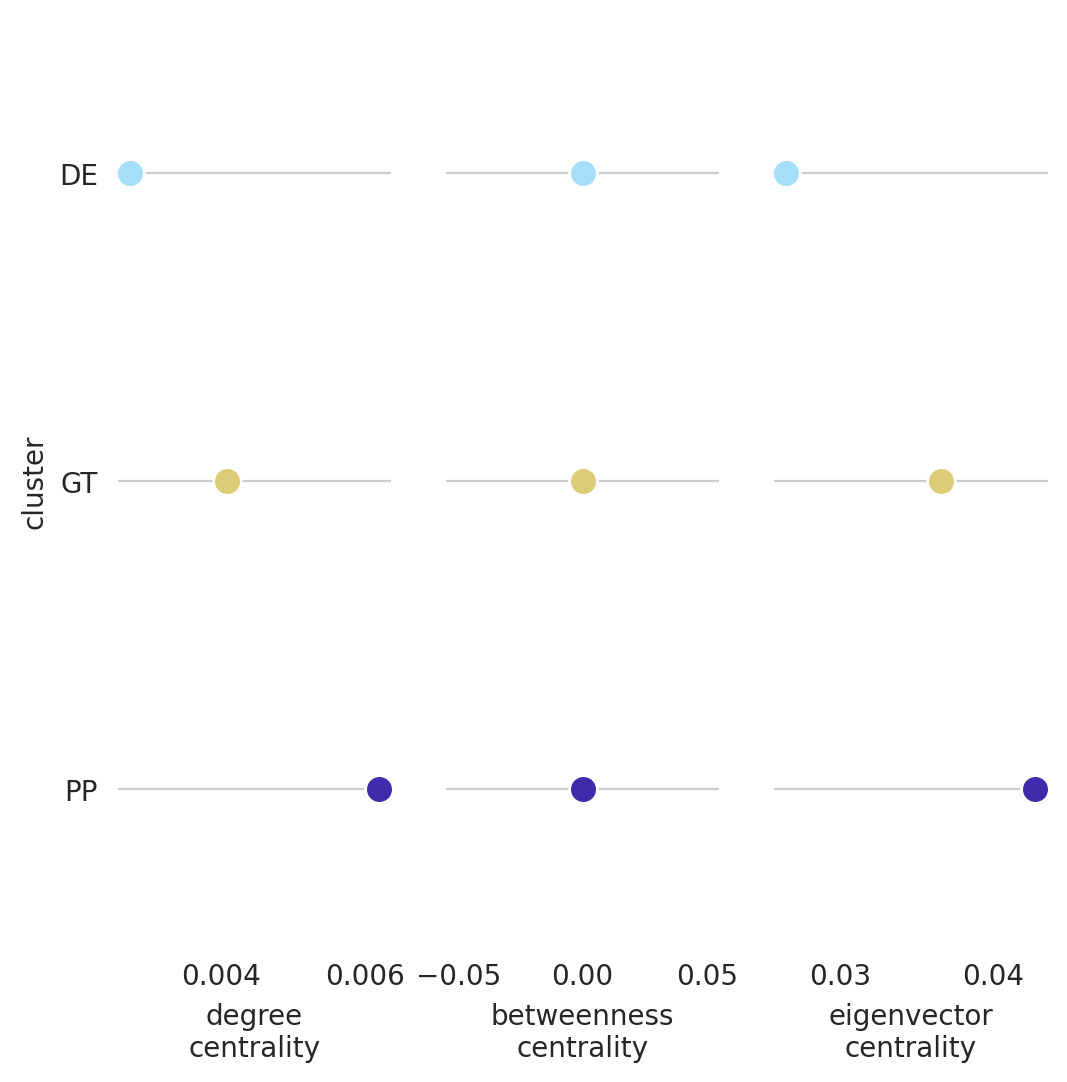

In [22]:
# Visualize X network score dynamics
links.plot_score_per_cluster(goi="SOX9", save=f"{save_folder}/network_score_per_gene/")
links.plot_score_per_cluster(goi="SOX17", save=f"{save_folder}/network_score_per_gene/")


LEFTY2


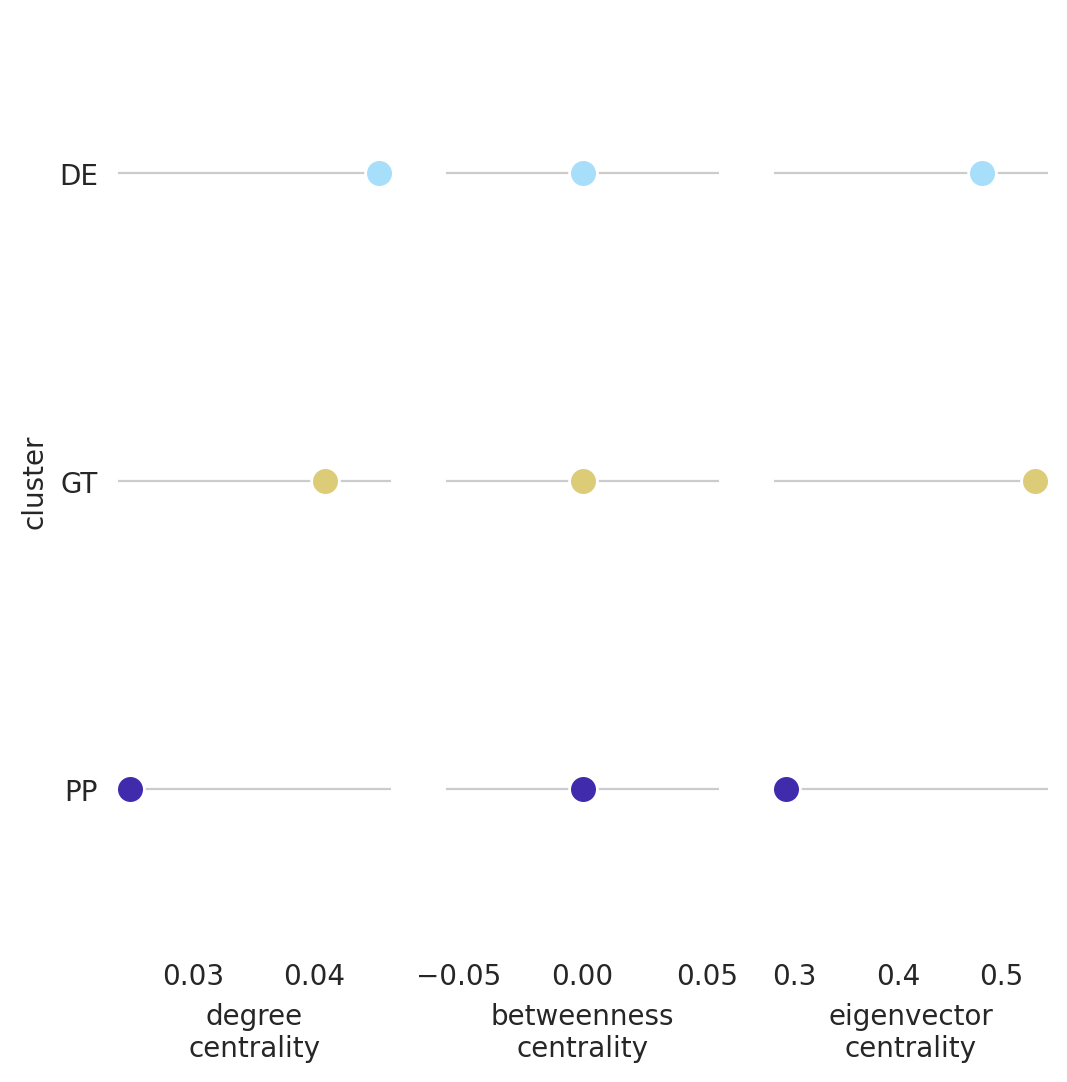

In [23]:
# Visualize X network score dynamics
links.plot_score_per_cluster(goi="LEFTY2", save=f"{save_folder}/network_score_per_gene/")


## TFs Ranked coef Fig. 3G

In [12]:
import os
import pandas as pd

# Combine all clusters into one table
all_targets_list = []

for cluster_name, cluster_df in links.filtered_links.items():
    temp = cluster_df.copy()
    temp["cell_state"] = cluster_name
    all_targets_list.append(temp)

all_targets_df = pd.concat(all_targets_list, ignore_index=True)

# Keep only the columns you want, if they exist
cols_to_keep = ["cell_state", "source", "target", "coef_mean", "coef_abs"]
cols_to_keep = [c for c in cols_to_keep if c in all_targets_df.columns]

all_targets_df = all_targets_df[cols_to_keep]

# Rename for clarity
all_targets_df = all_targets_df.rename(columns={
    "source": "TF",
    "target": "Target",
    "coef_mean": "Coefficient",
    "coef_abs": "Abs_Coefficient"
})

# Optional: sort nicely
all_targets_df = all_targets_df.sort_values(
    by=["cell_state", "TF", "Abs_Coefficient"],
    ascending=[True, True, False]
).reset_index(drop=True)

# Preview
print(all_targets_df.head())

# Save
output_dir = "outputs/celloracle_tables/DT_Subset_DE_GT_PP"
os.makedirs(output_dir, exist_ok=True)

all_targets_df.to_csv(
    os.path.join(output_dir, "All_TFs_all_targets_all_coefficients.csv"),
    index=False
) #Table S10


  cell_state     TF   Target  Coefficient  Abs_Coefficient
0         DE  ARID2   PTPN13     0.366931         0.366931
1         DE  ARID2  COLEC12     0.245866         0.245866
2         DE  ARID2     HM13     0.177033         0.177033
3         DE  ARID2   NDUFC2     0.151388         0.151388
4         DE  ARID2    RACK1     0.147724         0.147724


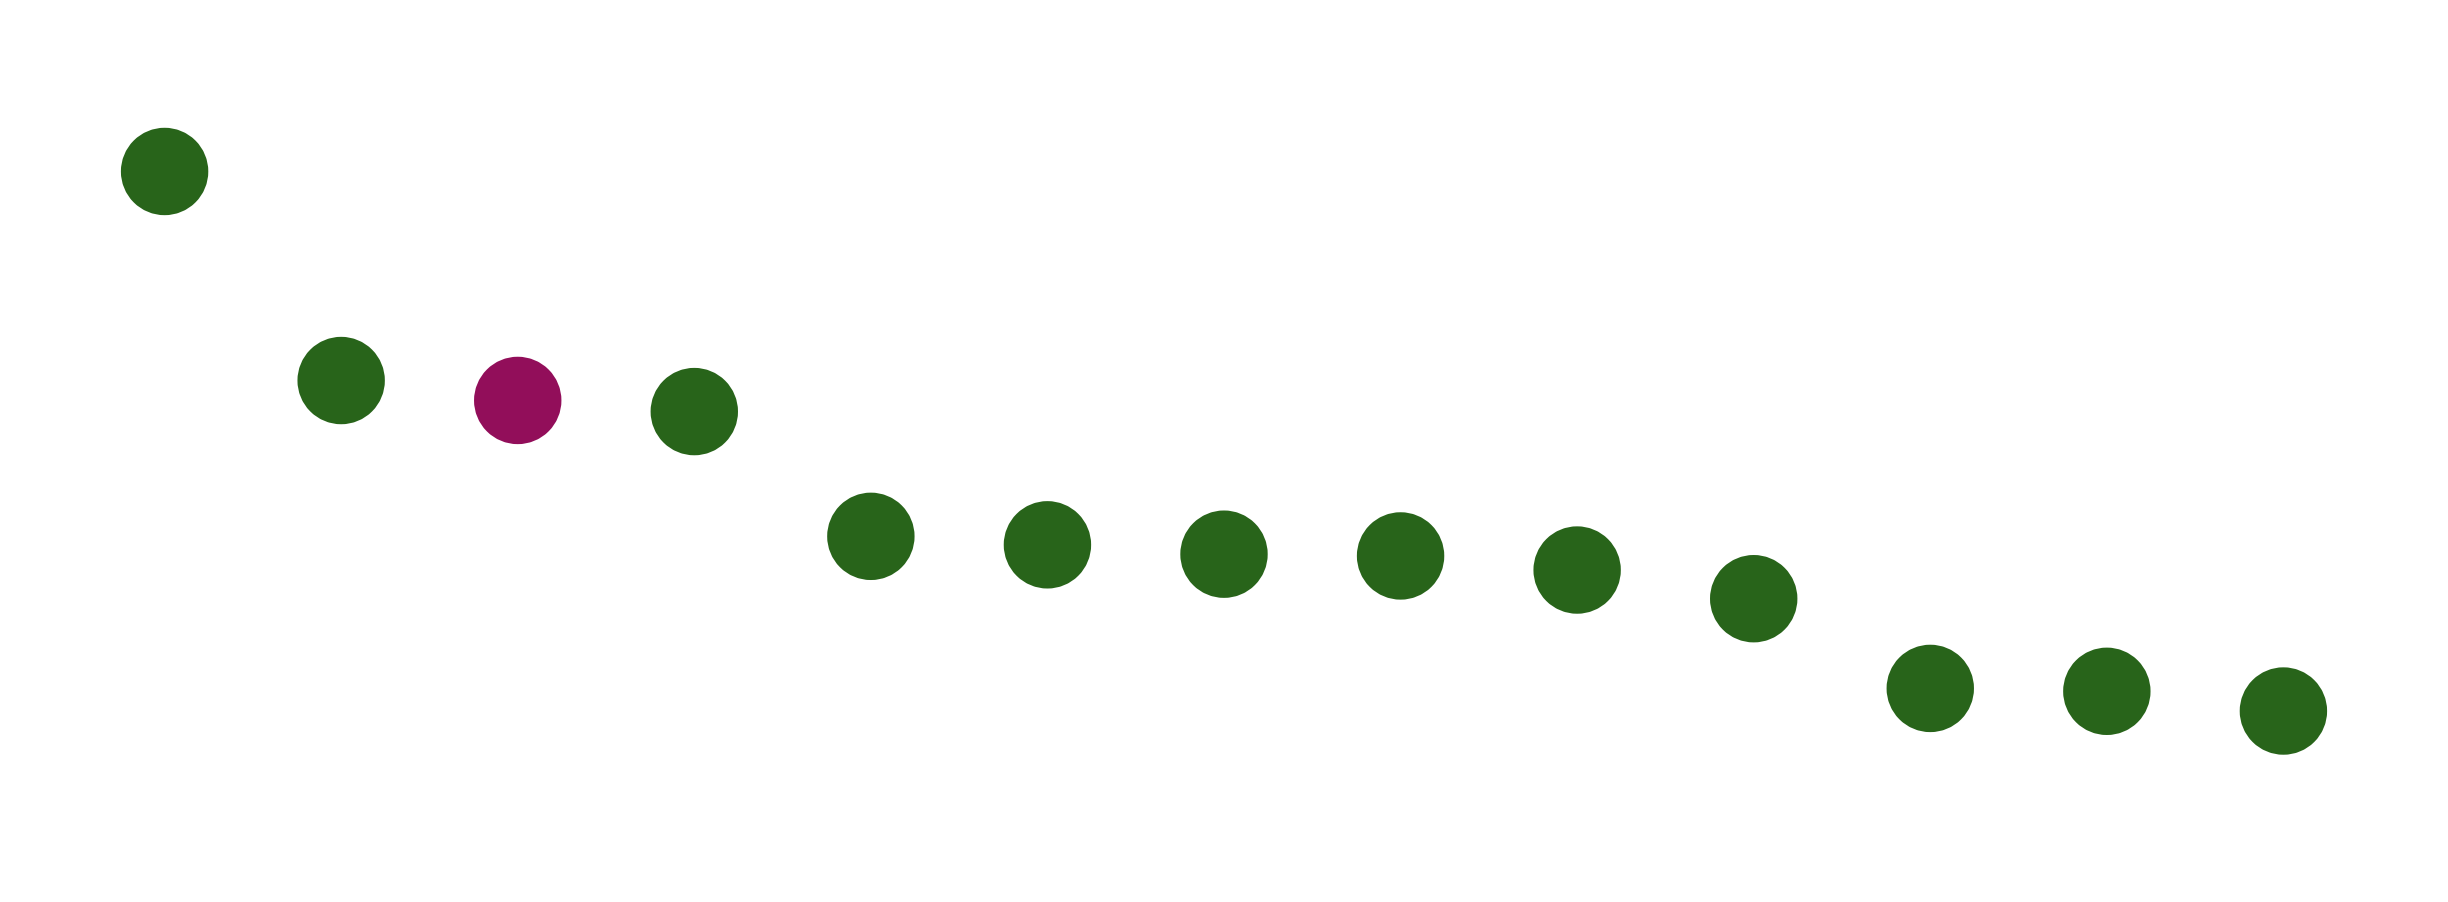

Figure saved to: outputs/celloracle_figures/DT_Subset_DE_GT_PP/GATA4_targets_PP_ranked_coefabs.png


['ATP5MC2',
 'SEMA3E',
 'TOX',
 'RPL35A',
 'PCDH7',
 'FAU',
 'SEMA3A',
 'ARHGAP42',
 'FGF17',
 'DNAJC15',
 'CXCR4',
 'PDE10A',
 'PHB2']

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "PP"
tf_name = "GATA4"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.0, 0.6
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.45
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)

# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/DT_Subset_DE_GT_PP"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


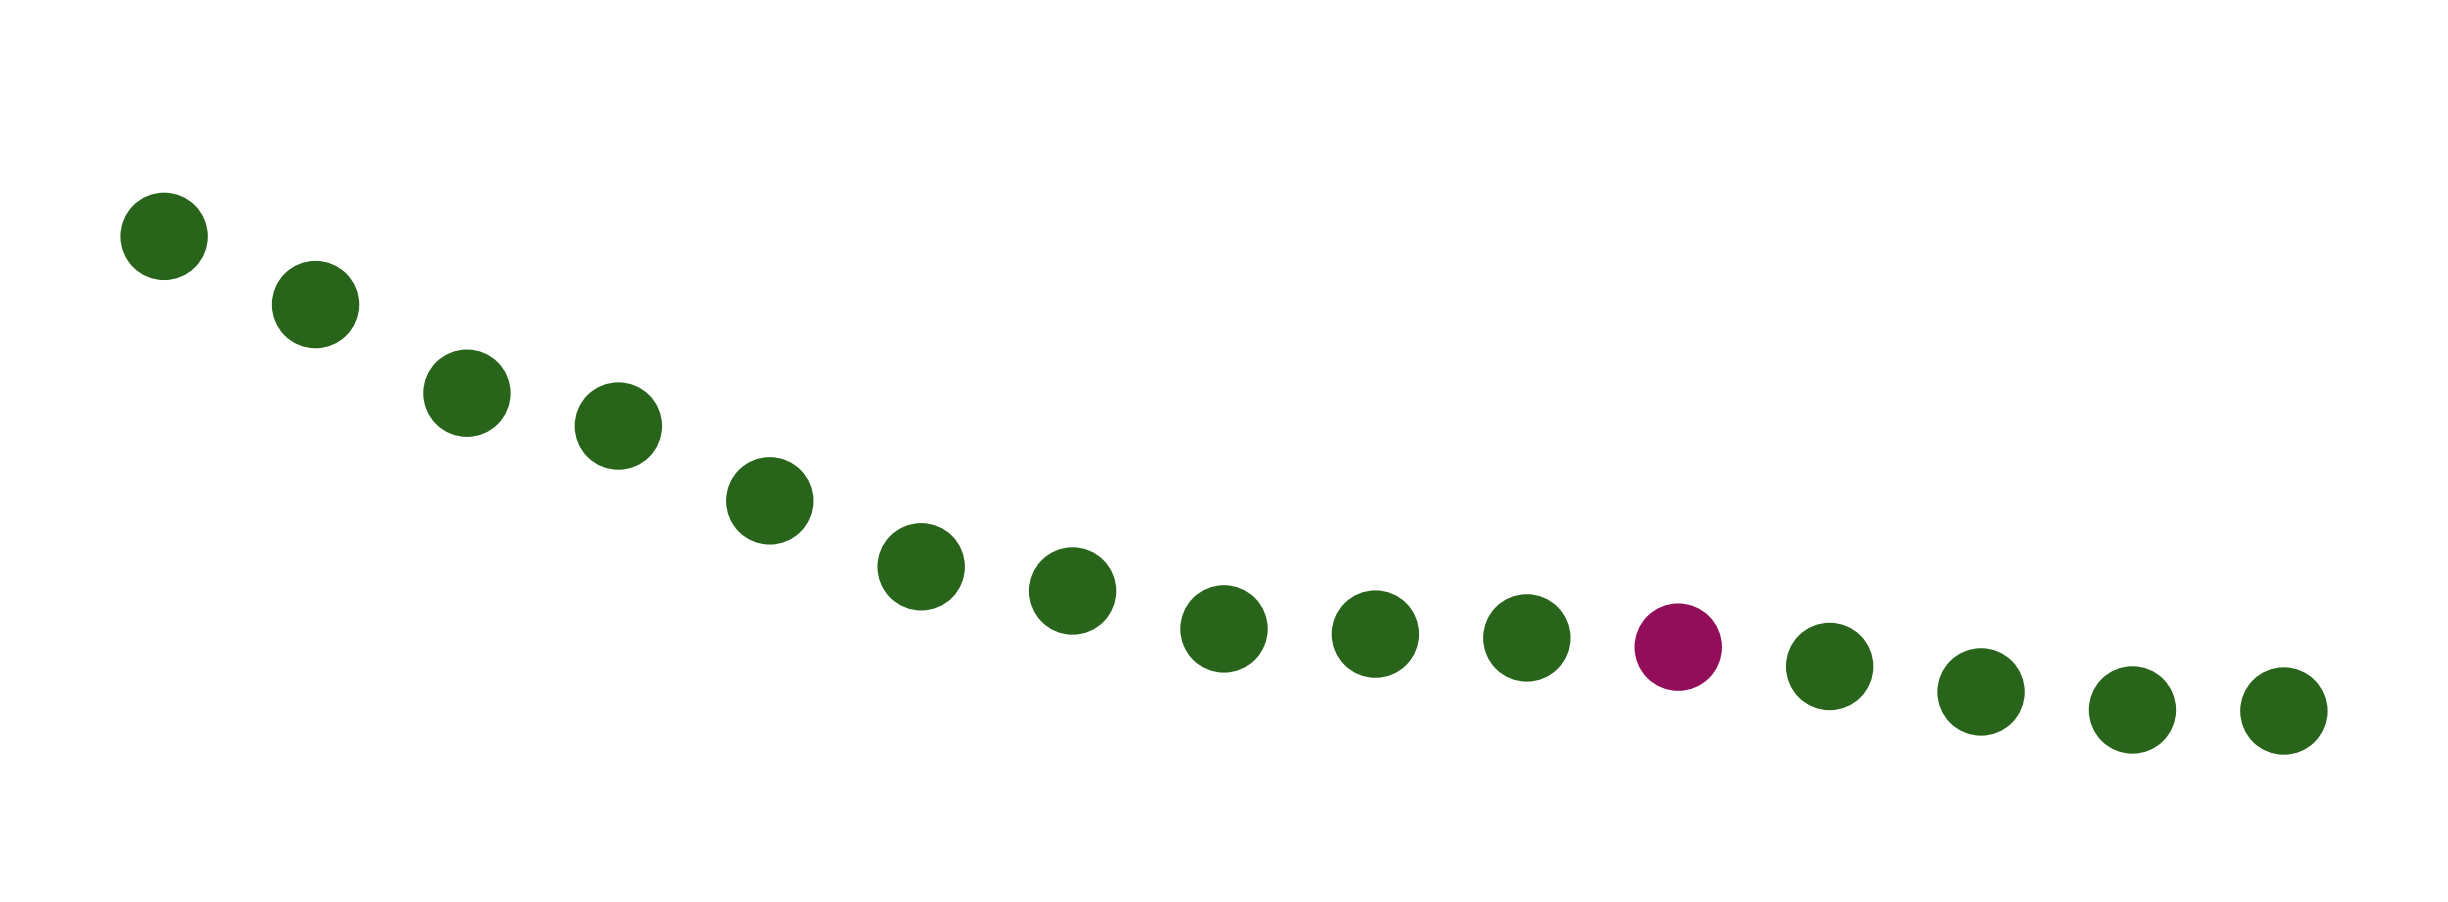

Figure saved to: outputs/celloracle_figures/DT_Subset_DE_GT_PP/GATA4_targets_GT_ranked_coefabs.png


['SEMA3E',
 'ARHGAP42',
 'PCDH7',
 'FGF17',
 'SEMA3A',
 'CXCR4',
 'CCDC141',
 'PDE10A',
 'ATP5MC2',
 'ANK2',
 'TOX',
 'DNAJC15',
 'FAU',
 'GRPR',
 'APC']

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "GT"
tf_name = "GATA4"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.0, 0.6
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.45
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)

# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/DT_Subset_DE_GT_PP"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


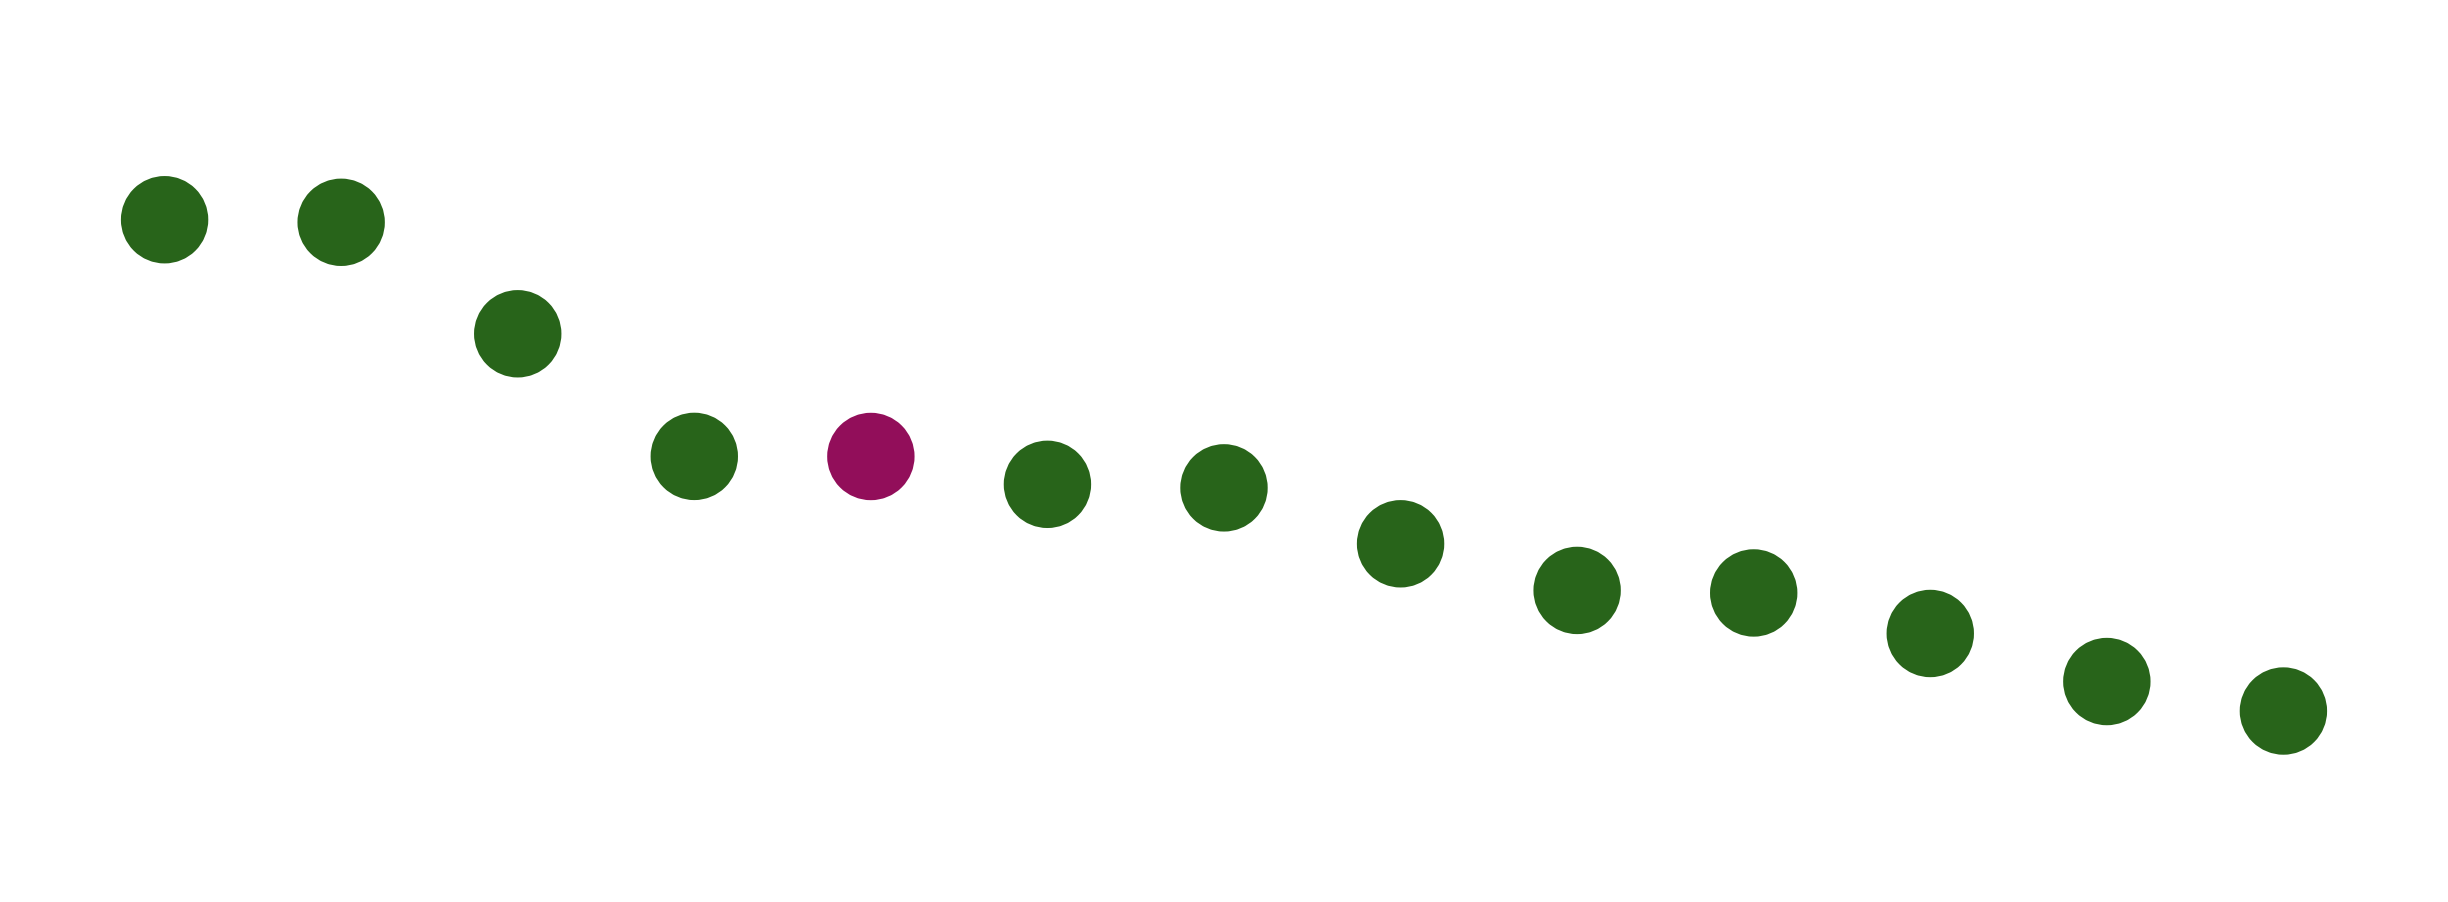

Figure saved to: outputs/celloracle_figures/DT_Subset_DE_GT_PP/GATA4_targets_DE_ranked_coefabs.png


['SEMA3E',
 'ARHGAP42',
 'PCDH7',
 'CCDC141',
 'RPL35A',
 'SEMA3A',
 'FGF17',
 'CXCR4',
 'DNAJC15',
 'ANK2',
 'PDE10A',
 'ANK3',
 'GRPR']

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "DE"
tf_name = "GATA4"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.0, 0.6
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.45
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)
# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/DT_Subset_DE_GT_PP"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


In [36]:
# Tiene una sonrisa que la risa se te infecta, y sabe lo que vale, a ella se la respeta. - La Beba by Temple Sour